# Notebook 06 — Track-Wise Strategy Analysis

---

## Purpose
This notebook delivers **circuit-specific, actionable strategy recommendations** for a mid-field F1 constructor. It answers six concrete questions per track:

1. **What compound family should we target?** (soft-biased vs hard-biased based on degradation)
2. **How many stops is optimal?** (1-stop / 2-stop / 3-stop by circuit archetype)
3. **When should we pit?** (optimal pit window — lap range)
4. **How much does qualifying position matter here?** (grid lock-in score)
5. **What is the expected position gain / loss risk?** (grid-to-finish delta distribution)
6. **How does the circuit cluster compare strategically?** (archetype benchmarking)

**Outputs:**
- `data/processed/track_strategy_profiles.csv` — machine-readable per-circuit strategy table
- `reports/figures/track_strategy_*.png` — chart set (one per analysis type)
- `reports/track_strategy_report.txt` — plain-text strategy cards for all circuits

## Section 0 — Imports, Constants, Setup

In [22]:
import os
import warnings
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal

warnings.filterwarnings('ignore')

# ── Visual style ──────────────────────────────────────────────────────────────
# F1-inspired dark theme with red accent
F1_RED    = '#E8002D'
F1_DARK   = '#15151E'
F1_GREY   = '#38383F'
F1_SILVER = '#C0C0C0'
F1_WHITE  = '#FFFFFF'
F1_GOLD   = '#FFD700'

COMPOUND_COLORS = {
    'SOFT':   '#E8002D',   # F1 red
    'MEDIUM': '#FFF200',   # F1 yellow
    'HARD':   '#FFFFFF',   # white
    'INTER':  '#39B54A',   # green
    'WET':    '#0067FF',   # blue
}

CLUSTER_COLORS = {
    'Qualifying-Dominant': '#E8002D',
    'Strategy-Dominant':   '#39B54A',
    'Mixed':               '#1F77B4',
}

plt.rcParams.update({
    'figure.facecolor':   F1_DARK,
    'axes.facecolor':     '#1E1E2A',
    'axes.edgecolor':     F1_GREY,
    'axes.labelcolor':    F1_SILVER,
    'axes.titlecolor':    F1_WHITE,
    'axes.titlesize':     13,
    'axes.titleweight':   'bold',
    'axes.labelsize':     10,
    'xtick.color':        F1_SILVER,
    'ytick.color':        F1_SILVER,
    'xtick.labelsize':    9,
    'ytick.labelsize':    9,
    'legend.facecolor':   '#1E1E2A',
    'legend.edgecolor':   F1_GREY,
    'legend.labelcolor':  F1_SILVER,
    'legend.fontsize':    9,
    'text.color':         F1_WHITE,
    'grid.color':         F1_GREY,
    'grid.alpha':         0.4,
    'figure.figsize':     (14, 7),
})

# ── Paths ─────────────────────────────────────────────────────────────────────
PROCESSED_PATH = '../data/processed/'
FIGURES_PATH   = '../reports/figures/'
REPORTS_PATH   = '../reports/'
os.makedirs(FIGURES_PATH, exist_ok=True)
os.makedirs(REPORTS_PATH, exist_ok=True)

# ── Analysis constants ────────────────────────────────────────────────────────
MIN_YEAR     = 2010   # Pit stop data dense from 2010
MIN_RACES    = 3      # Min races at a circuit to include in analysis
ALPHA        = 0.05

# Typical F1 race lap counts by circuit (used for pit window estimation)
# Source: Ergast circuit reference + well-known F1 lap counts
CIRCUIT_LAPS = {
    'albert_park':    58, 'bahrain':      57, 'catalunya':     66,
    'monaco':         78, 'baku':         51, 'silverstone':   52,
    'hungaroring':    70, 'spa':          44, 'monza':         53,
    'marina_bay':     61, 'suzuka':       53, 'americas':      56,
    'rodriguez':      71, 'interlagos':   71, 'yas_marina':    58,
    'red_bull_ring':  71, 'paul_ricard':  53, 'hockenheimring':67,
    'shanghai':       56, 'sochi':        53, 'zandvoort':     72,
    'losail':         57, 'jeddah':       50, 'imola':         63,
    'portimao':       66, 'istanbul':     58, 'nurburgring':   60,
    'miami':          57, 'las_vegas':    50, 'lusail':        57,
}
DEFAULT_LAPS = 57   # fallback if circuit not in dict

print('Setup complete.')
print(f'Analysis scope: {MIN_YEAR}+ | Min races per circuit: {MIN_RACES}')

Setup complete.
Analysis scope: 2010+ | Min races per circuit: 3


## Section 1 — Load Processed Data

In [23]:
# ── Load master fact and circuit profile ──────────────────────────────────────
master      = pd.read_csv(os.path.join(PROCESSED_PATH, 'master_fact.csv'),      low_memory=False)
ckt_profile = pd.read_csv(os.path.join(PROCESSED_PATH, 'circuit_strategy_profile.csv'))

print(f'master_fact       : {master.shape}')
print(f'circuit_profile   : {ckt_profile.shape}')

# ── Numeric coercion guard (CSV round-trip) ───────────────────────────────────
MASTER_NUMERIC = [
    'year','grid','positionOrder','points','stop_count','avg_pit_ms',
    'fastest_pit_ms','qualifying_gap_ms','grid_to_finish_delta',
    'lap_time_std','fastest_lap_ms','lap_count','lat','lng'
]
for col in MASTER_NUMERIC:
    if col in master.columns:
        master[col] = pd.to_numeric(master[col], errors='coerce')

PROFILE_NUMERIC = [
    'avg_delta','avg_qualifying_gap','lap_time_variance',
    'avg_1stop_position','avg_2stop_position','best_strategy_stops',
    'total_races'
]
for col in PROFILE_NUMERIC:
    if col in ckt_profile.columns:
        ckt_profile[col] = pd.to_numeric(ckt_profile[col], errors='coerce')

# ── Boolean guard ─────────────────────────────────────────────────────────────
if master['is_finisher'].dtype != bool:
    master['is_finisher'] = master['is_finisher'].astype(str).str.lower().isin(['true','1'])

# ── Ensure cluster_label exists (fallback if notebook 04 not run yet) ─────────
if 'cluster_label' not in ckt_profile.columns:
    ckt_profile['cluster_label'] = 'Mixed'
    print('[WARN] cluster_label missing in circuit_profile — defaulting to "Mixed".')
    print('       Run 04_statistical_analysis.ipynb first for full clustering.')

# ── Working scope ─────────────────────────────────────────────────────────────
scope = master[
    (master['year']        >= MIN_YEAR) &
    (master['is_finisher'] == True) &
    (master['grid']        >  0)
].copy()

print(f'\nWorking scope (2010+, finishers, grid>0): {len(scope):,} rows')
print(f'Circuits in scope: {scope["circuitId"].nunique()}')
print(f'Seasons in scope : {sorted(scope["year"].dropna().astype(int).unique())}')

master_fact       : (27304, 57)
circuit_profile   : (78, 15)

Working scope (2010+, finishers, grid>0): 5,673 rows
Circuits in scope: 35
Seasons in scope : [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


## Section 2 — Tyre Compound Strategy Classification

**Logic:** We do not have compound labels in the Ergast dataset, but we can infer compound preference from observable proxies:
- **Lap-time degradation rate** (`lap_time_std`): high std = high tyre wear → soft-biased circuits reward aggressive tyre choice and more stops
- **Stop count distribution**: more stops → harder to run a long first stint → soft compounds probable
- **Fastest pit milliseconds**: circuits with very fast pits encourage more stops → softer compound strategy viable

We classify each circuit's **compound bias** as: `SOFT-biased`, `MEDIUM-biased`, or `HARD-biased`.

In [24]:
# ── Per-circuit degradation and stop-count aggregation ────────────────────────
ckt_agg = (
    scope[scope['stop_count'].notna() & scope['lap_time_std'].notna()]
    .groupby('circuitId', as_index=False)
    .agg(
        circuit_name    = ('circuit_name',           'first'),
        country         = ('country',                'first'),
        n_races         = ('raceId',                 'nunique'),
        avg_stop_count  = ('stop_count',             'mean'),
        pct_1stop       = ('stop_count',             lambda x: (x == 1).mean()),
        pct_2stop       = ('stop_count',             lambda x: (x == 2).mean()),
        pct_3stop       = ('stop_count',             lambda x: (x == 3).mean()),
        med_lap_std     = ('lap_time_std',           'median'),
        avg_lap_std     = ('lap_time_std',           'mean'),
        avg_delta       = ('grid_to_finish_delta',   'mean'),
        avg_pit_ms      = ('avg_pit_ms',             'mean'),
        fastest_pit_ms  = ('fastest_pit_ms',         'mean'),
        avg_qual_gap    = ('qualifying_gap_ms',      'mean'),
        avg_position    = ('positionOrder',          'mean'),
    )
    .query('n_races >= @MIN_RACES')
    .copy()
)

print(f'[STEP 2] Circuits with sufficient data: {len(ckt_agg)}')

# ── Degradation percentile rank ───────────────────────────────────────────────
ckt_agg['deg_rank_pct'] = ckt_agg['avg_lap_std'].rank(pct=True)

# ── Compound bias classification ──────────────────────────────────────────────
# High degradation + high avg stops → SOFT-biased (frequent stops needed)
# Low degradation + low avg stops   → HARD-biased (1-stop viable)
# Middle tier                        → MEDIUM-biased
def classify_compound_bias(row) -> str:
    """Classify circuit tyre compound bias from degradation and stop-count proxies."""
    deg_pct    = row['deg_rank_pct']
    avg_stops  = row['avg_stop_count']
    pct_3plus  = row['pct_3stop']

    if deg_pct >= 0.70 or (avg_stops >= 2.2 and pct_3plus >= 0.10):
        return 'SOFT-biased'
    elif deg_pct <= 0.35 or avg_stops <= 1.55:
        return 'HARD-biased'
    else:
        return 'MEDIUM-biased'

ckt_agg['compound_bias'] = ckt_agg.apply(classify_compound_bias, axis=1)

print('[STEP 2] Compound bias distribution:')
display(ckt_agg['compound_bias'].value_counts().reset_index())
print('\n[STEP 2] Per-circuit compound bias:')
display(ckt_agg[['circuit_name','country','avg_stop_count','avg_lap_std','deg_rank_pct','compound_bias']]
        .sort_values('avg_lap_std', ascending=False).round(3))

[STEP 2] Circuits with sufficient data: 33
[STEP 2] Compound bias distribution:


,compound_bias,count
0,SOFT-biased,17
1,HARD-biased,10
2,MEDIUM-biased,6



[STEP 2] Per-circuit compound bias:


,circuit_name,country,avg_stop_count,avg_lap_std,deg_rank_pct,compound_bias
22,Korean International Circuit,Korea,1.893,84028.480,1.000,SOFT-biased
7,Silverstone Circuit,UK,1.913,78557.876,0.970,SOFT-biased
6,Circuit Gilles Villeneuve,Canada,2.025,70643.198,0.939,SOFT-biased
1,Sepang International Circuit,Malaysia,2.565,70347.402,0.909,SOFT-biased
23,Circuit Park Zandvoort,Netherlands,2.812,61000.385,0.879,SOFT-biased
28,Baku City Circuit,Azerbaijan,1.877,60102.515,0.848,SOFT-biased
5,Circuit de Monaco,Monaco,1.638,55383.454,0.818,SOFT-biased
31,Jeddah Corniche Circuit,Saudi Arabia,1.390,53970.212,0.788,SOFT-biased
17,Autodromo Enzo e Dino Ferrari,Italy,1.847,45974.485,0.758,SOFT-biased
15,Autódromo José Carlos Pace,Brazil,2.677,44617.644,0.727,SOFT-biased


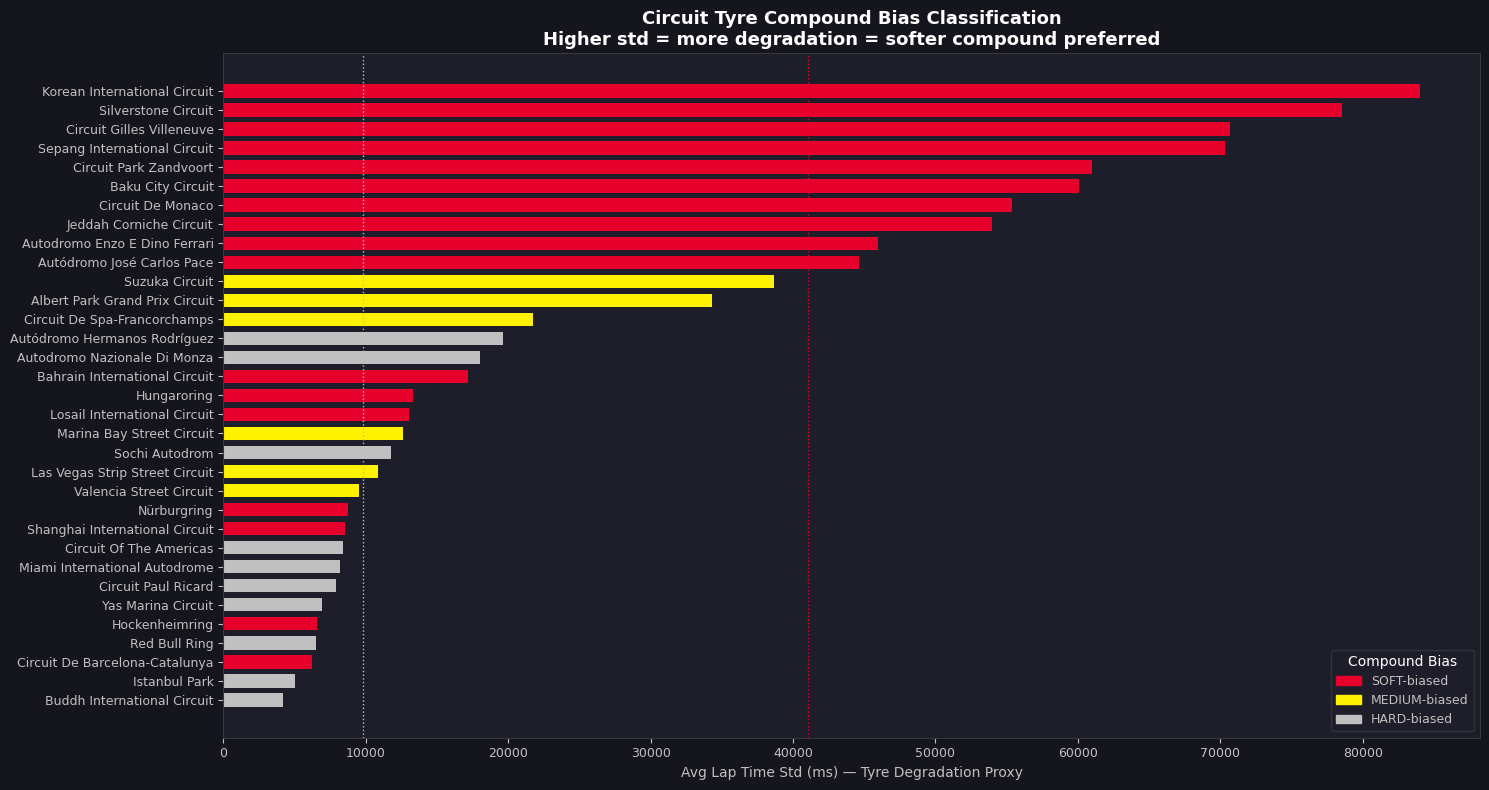

[STEP 2] Chart saved: track_01_compound_bias.png


In [25]:
# ── Chart 1: Compound bias ranking — avg lap_time_std per circuit ──────────────
plot_deg = ckt_agg.sort_values('avg_lap_std', ascending=True).copy()

BIAS_COLORS = {
    'SOFT-biased':   F1_RED,
    'MEDIUM-biased': '#FFF200',
    'HARD-biased':   F1_SILVER,
}
bar_colors = plot_deg['compound_bias'].map(BIAS_COLORS).fillna(F1_GREY)

fig, ax = plt.subplots(figsize=(15, 8))
bars = ax.barh(
    plot_deg['circuit_name'].str.replace('_', ' ').str.title(),
    plot_deg['avg_lap_std'],
    color=bar_colors, edgecolor='none', height=0.7
)

# Compound bias legend
legend_patches = [
    mpatches.Patch(color=BIAS_COLORS[b], label=b) for b in BIAS_COLORS
]
ax.legend(handles=legend_patches, title='Compound Bias', loc='lower right')
ax.set_xlabel('Avg Lap Time Std (ms) — Tyre Degradation Proxy')
ax.set_title('Circuit Tyre Compound Bias Classification\n'
             'Higher std = more degradation = softer compound preferred',
             color=F1_WHITE)
ax.axvline(plot_deg['avg_lap_std'].quantile(0.35), color=F1_SILVER, linestyle=':', linewidth=1,
           label='Hard/Medium threshold')
ax.axvline(plot_deg['avg_lap_std'].quantile(0.70), color=F1_RED, linestyle=':', linewidth=1,
           label='Medium/Soft threshold')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}track_01_compound_bias.png', dpi=150, bbox_inches='tight',
            facecolor=F1_DARK)
plt.show()
print('[STEP 2] Chart saved: track_01_compound_bias.png')

## Section 3 — Optimal Stop Count per Circuit

For each circuit we compute the **mean finishing position** by stop count, then identify which stop count yields the best (lowest) average finish among classified finishers. We also perform a Kruskal-Wallis test to verify whether stop-count differences are statistically significant.

In [26]:
# ── Stop-count performance per circuit (1-3 stops only) ──────────────────────
stop_df = scope[
    scope['stop_count'].notna() &
    scope['stop_count'].between(1, 3)
].copy()
stop_df['stop_count'] = stop_df['stop_count'].astype(int)

stop_perf = (
    stop_df
    .groupby(['circuitId', 'circuit_name', 'stop_count'], as_index=False)
    .agg(
        mean_position = ('positionOrder', 'mean'),
        median_pos    = ('positionOrder', 'median'),
        n             = ('resultId',      'count'),
    )
)

# Filter circuits with enough data on at least 2 stop counts
circuit_stop_counts = stop_perf.groupby('circuitId')['stop_count'].nunique()
valid_circuits = circuit_stop_counts[circuit_stop_counts >= 2].index
stop_perf = stop_perf[stop_perf['circuitId'].isin(valid_circuits)].copy()

# ── Best stop count per circuit ───────────────────────────────────────────────
best_stop = (
    stop_perf
    .sort_values('mean_position')
    .groupby('circuitId', as_index=False)
    .first()
    [['circuitId', 'stop_count', 'mean_position']]
    .rename(columns={'stop_count': 'optimal_stops', 'mean_position': 'optimal_avg_pos'})
)

ckt_agg = ckt_agg.merge(best_stop, on='circuitId', how='left')

# ── Kruskal-Wallis: is stop_count difference significant per circuit? ─────────
kw_results = []
for ckt_id in valid_circuits:
    grp_data  = stop_df[stop_df['circuitId'] == ckt_id]
    groups    = [grp_data[grp_data['stop_count'] == s]['positionOrder'].dropna().values
                 for s in [1, 2, 3]]
    groups    = [g for g in groups if len(g) >= 3]   # min 3 obs per group
    if len(groups) >= 2:
        stat, p = kruskal(*groups)
        ckt_name = grp_data['circuit_name'].iloc[0]
        kw_results.append({'circuitId': ckt_id, 'circuit_name': ckt_name,
                           'kw_stat': stat, 'kw_p': p,
                           'stop_sig': p < ALPHA})

kw_df = pd.DataFrame(kw_results)
sig_count = kw_df['stop_sig'].sum() if not kw_df.empty else 0
total_count = len(kw_df)
print(f'[STEP 3] Kruskal-Wallis: {sig_count}/{total_count} circuits show significant '
      f'stop-count effect on finish position (α={ALPHA})')
display(kw_df[kw_df['stop_sig']].sort_values('kw_p')[['circuit_name','kw_stat','kw_p']].round(4))

[STEP 3] Kruskal-Wallis: 12/34 circuits show significant stop-count effect on finish position (α=0.05)


,circuit_name,kw_stat,kw_p
5,Circuit de Monaco,17.6902,0.0001
27,Sochi Autodrom,12.9169,0.0003
13,Marina Bay Street Circuit,15.5080,0.0004
2,Bahrain International Circuit,11.5571,0.0031
19,Yas Marina Circuit,7.8774,0.0195
11,Circuit de Spa-Francorchamps,7.8718,0.0195
22,Korean International Circuit,7.4650,0.0239
17,Autodromo Enzo e Dino Ferrari,7.1413,0.0281
0,Albert Park Grand Prix Circuit,7.0782,0.0290
14,Shanghai International Circuit,6.9182,0.0315


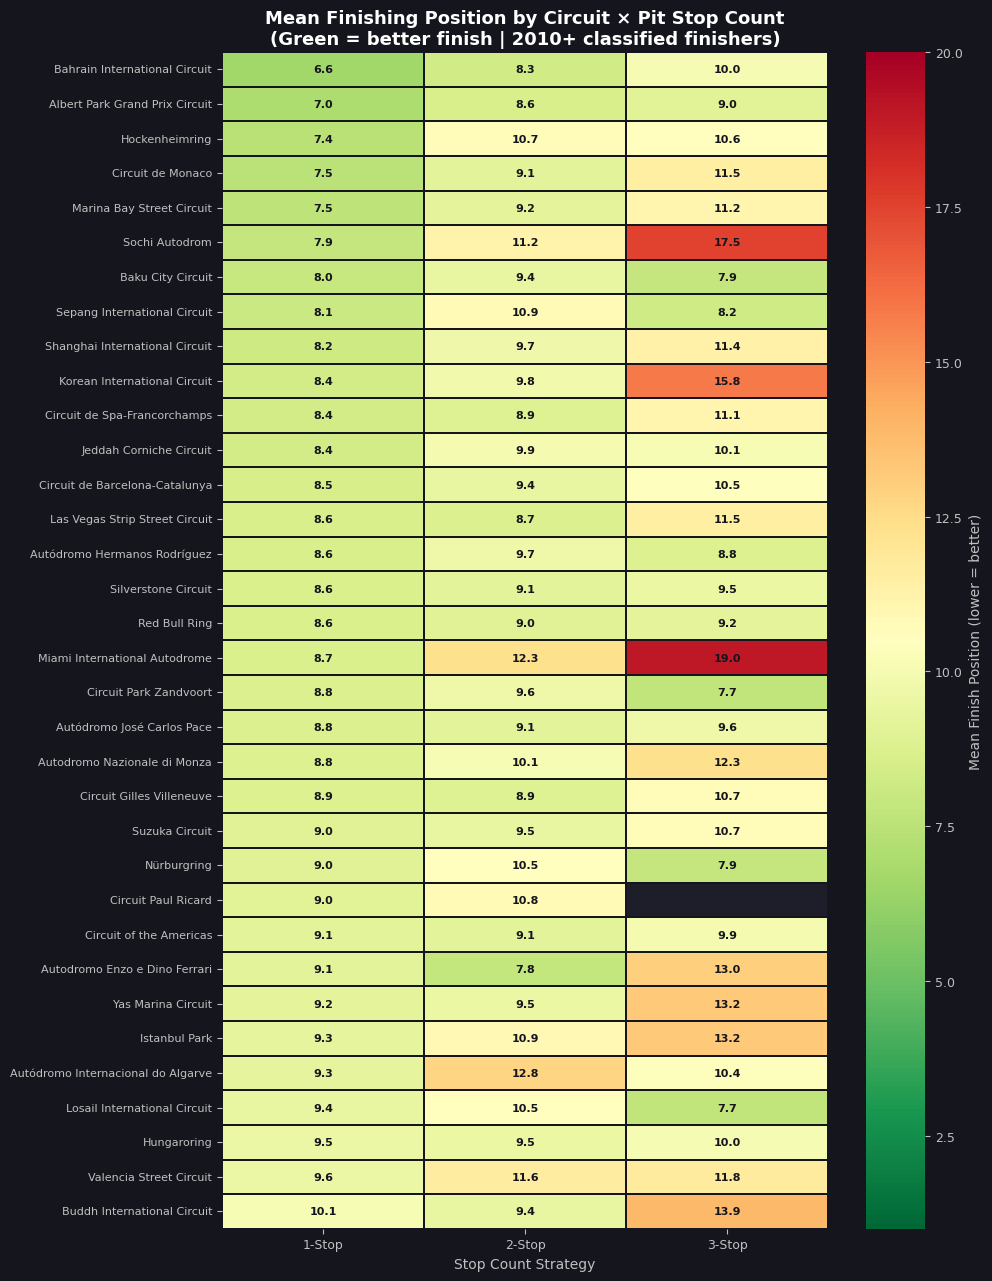

[STEP 3] Chart saved: track_02_stop_count_heatmap.png


In [27]:
# ── Chart 2: Heatmap — mean position by circuit × stop count ─────────────────
pivot_pos = stop_perf.pivot_table(
    index='circuit_name', columns='stop_count', values='mean_position'
)
pivot_pos.columns = [f'{int(c)}-Stop' for c in pivot_pos.columns]
pivot_pos = pivot_pos.sort_values('1-Stop', na_position='last')

fig, ax = plt.subplots(figsize=(10, max(8, len(pivot_pos) * 0.38)))
sns.heatmap(
    pivot_pos, annot=True, fmt='.1f', cmap='RdYlGn_r',
    linewidths=0.3, linecolor=F1_DARK,
    cbar_kws={'label': 'Mean Finish Position (lower = better)'},
    ax=ax, vmin=1, vmax=20,
    annot_kws={'size': 8, 'color': F1_DARK, 'weight': 'bold'}
)
ax.set_title('Mean Finishing Position by Circuit × Pit Stop Count\n'
             '(Green = better finish | 2010+ classified finishers)', color=F1_WHITE)
ax.set_xlabel('Stop Count Strategy')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}track_02_stop_count_heatmap.png', dpi=150, bbox_inches='tight',
            facecolor=F1_DARK)
plt.show()
print('[STEP 3] Chart saved: track_02_stop_count_heatmap.png')

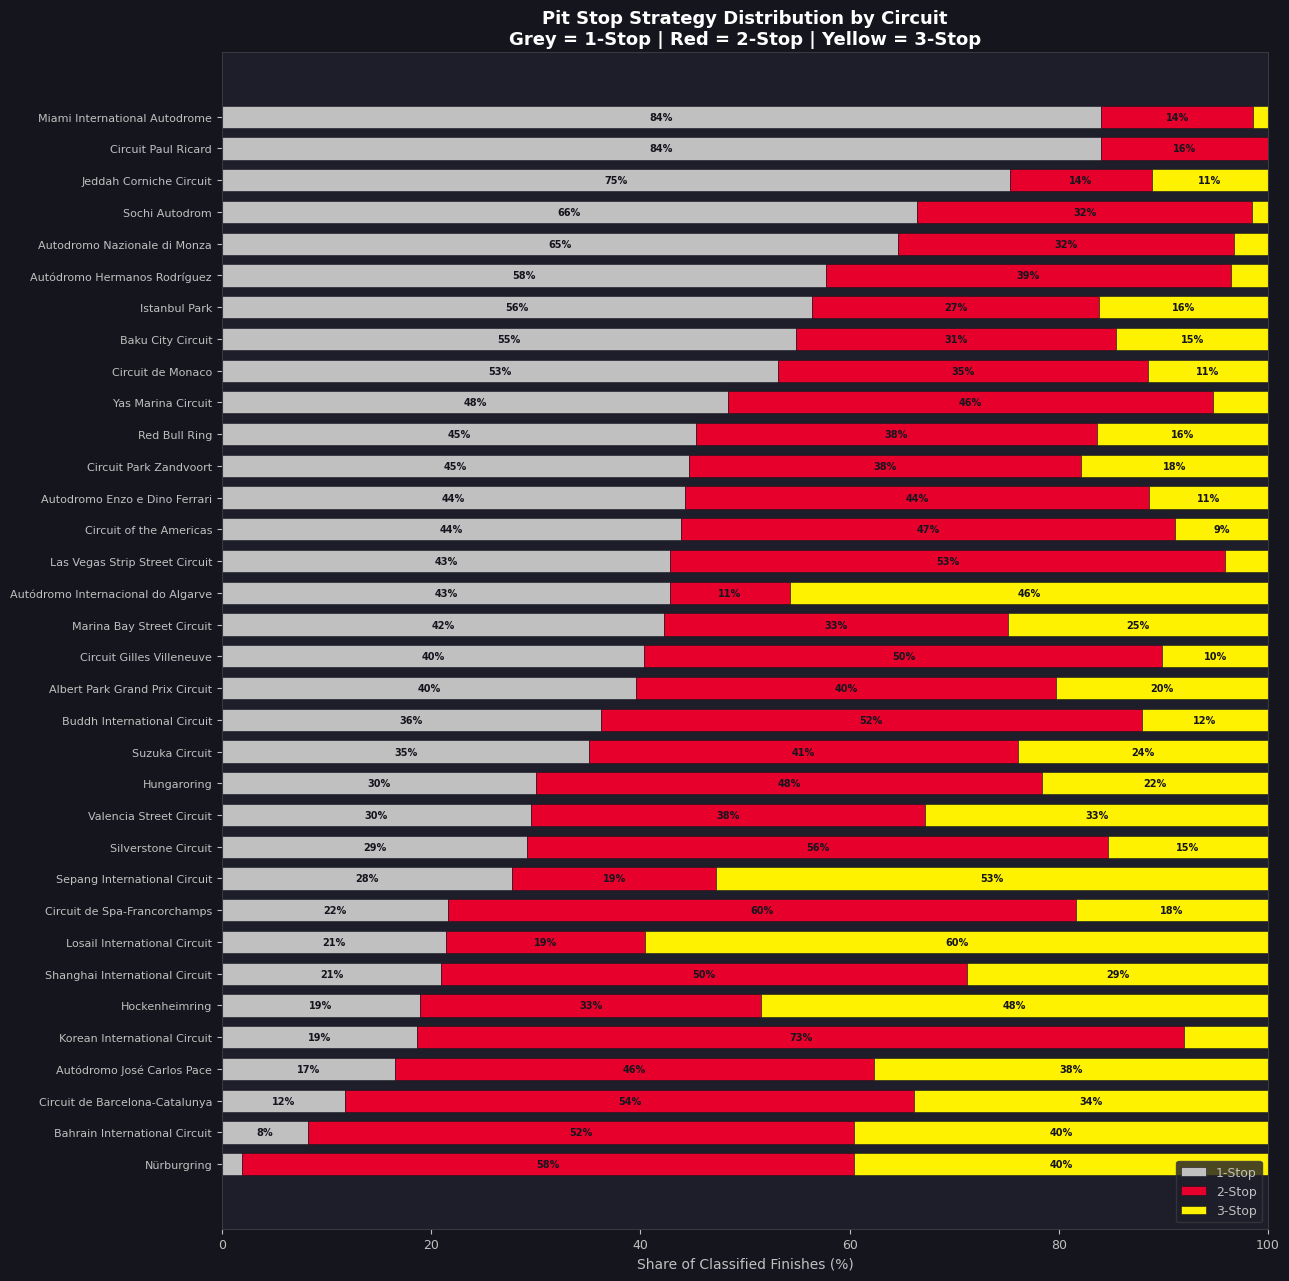

[STEP 3] Chart saved: track_03_stop_distribution.png


In [28]:
# ── Chart 3: Stacked bar — stop count distribution per circuit ────────────────
stop_pct = (
    stop_df
    .groupby(['circuit_name', 'stop_count'])['resultId']
    .count()
    .unstack(fill_value=0)
)
stop_pct = stop_pct.div(stop_pct.sum(axis=1), axis=0) * 100
stop_pct.columns = [f'{int(c)}-Stop' for c in stop_pct.columns]

# Sort by 1-stop share descending (most 1-stop-friendly at top)
if '1-Stop' in stop_pct.columns:
    stop_pct = stop_pct.sort_values('1-Stop', ascending=True)

STOP_COLORS = {f'{i}-Stop': c for i, c in
               zip([1, 2, 3], [F1_SILVER, F1_RED, '#FFF200'])}

fig, ax = plt.subplots(figsize=(13, max(7, len(stop_pct) * 0.38)))
left = np.zeros(len(stop_pct))
for col in stop_pct.columns:
    color = STOP_COLORS.get(col, F1_GREY)
    ax.barh(stop_pct.index, stop_pct[col], left=left,
            color=color, edgecolor=F1_DARK, linewidth=0.4,
            label=col, height=0.7)
    # Annotate pct if wide enough
    for i, (val, lft) in enumerate(zip(stop_pct[col], left)):
        if val > 8:
            ax.text(lft + val / 2, i, f'{val:.0f}%',
                    ha='center', va='center', fontsize=7,
                    color=F1_DARK, fontweight='bold')
    left = left + stop_pct[col].values

ax.set_xlim(0, 100)
ax.set_xlabel('Share of Classified Finishes (%)')
ax.set_title('Pit Stop Strategy Distribution by Circuit\n'
             'Grey = 1-Stop | Red = 2-Stop | Yellow = 3-Stop', color=F1_WHITE)
ax.legend(loc='lower right')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}track_03_stop_distribution.png', dpi=150, bbox_inches='tight',
            facecolor=F1_DARK)
plt.show()
print('[STEP 3] Chart saved: track_03_stop_distribution.png')

## Section 4 — Optimal Pit Window Estimation

We estimate the **optimal pit window** (lap range) for each circuit using the actual pit stop lap data from `pit_stops.csv` (proxied via the lap count at which each stop occurred).  
The pit window is defined as the **10th–90th percentile lap range** of the first and second stop laps at each circuit, separately for 1-stop and 2-stop strategies.

**If lap data per stop is unavailable** (it requires raw pit_stops.csv), we derive pit windows from `lap_count` (total race laps) and the stop count distribution:
- 1-stop: window = [35–45% of race distance, 50–65%]
- 2-stop: windows = [20–30%, 55–65%] of race distance

In [29]:
# ── Attempt to load raw pit_stops for per-lap data ────────────────────────────
raw_pit_path = '../data/raw/pit_stops.csv'
has_raw_pit  = os.path.exists(raw_pit_path)

if has_raw_pit:
    pit_raw = pd.read_csv(raw_pit_path, dtype=str)
    pit_raw.replace(r'\N', pd.NA, inplace=True)
    for col in ['lap', 'stop', 'milliseconds']:
        pit_raw[col] = pd.to_numeric(pit_raw[col], errors='coerce')
    # Merge year onto pit_raw
    races_ref = master[['raceId','year','circuitId','circuit_name','country']].drop_duplicates('raceId')
    races_ref['raceId'] = races_ref['raceId'].astype(str)
    pit_raw['raceId'] = pit_raw['raceId'].astype(str)
    pit_raw = pit_raw.merge(races_ref, on='raceId', how='left')
    pit_raw_scope = pit_raw[(pit_raw['year'] >= MIN_YEAR) & pit_raw['lap'].notna()].copy()
    print(f'[STEP 4] Raw pit_stops loaded: {len(pit_raw_scope):,} rows (2010+)')
else:
    pit_raw_scope = None
    print('[STEP 4] Raw pit_stops.csv not found — using formula-based pit windows.')

# ── Helper: get total laps for a circuit ──────────────────────────────────────
def get_total_laps(circuit_id: str) -> int:
    """Return typical race lap count for a circuit, falling back to default."""
    cid_clean = str(circuit_id).lower().replace(' ', '_')
    for key, laps in CIRCUIT_LAPS.items():
        if key in cid_clean or cid_clean in key:
            return laps
    # Also try from master: median lap_count for this circuit
    if 'lap_count' in master.columns:
        ckt_laps = master[
            (master['circuitId'].astype(str) == str(circuit_id)) &
            master['lap_count'].notna()
        ]['lap_count'].median()
        if pd.notna(ckt_laps) and ckt_laps > 0:
            return int(round(ckt_laps))
    return DEFAULT_LAPS

# ── Build pit window table ─────────────────────────────────────────────────────
pit_windows = []

for _, row in ckt_agg.iterrows():
    ckt_id   = row['circuitId']
    ckt_name = row['circuit_name']
    total    = get_total_laps(str(ckt_id))

    if has_raw_pit and pit_raw_scope is not None:
        ckt_pits = pit_raw_scope[
            (pit_raw_scope['circuitId'].astype(str) == str(ckt_id))
        ]
        # First stop (stop==1)
        stop1 = ckt_pits[ckt_pits['stop'] == 1]['lap'].dropna()
        # Second stop (stop==2)
        stop2 = ckt_pits[ckt_pits['stop'] == 2]['lap'].dropna()

        s1_lo = stop1.quantile(0.15) if len(stop1) >= 5 else total * 0.30
        s1_hi = stop1.quantile(0.85) if len(stop1) >= 5 else total * 0.55
        s2_lo = stop2.quantile(0.15) if len(stop2) >= 5 else total * 0.55
        s2_hi = stop2.quantile(0.85) if len(stop2) >= 5 else total * 0.75
        data_src = 'actual'
    else:
        # Formula-based fallback using empirical F1 pit-window knowledge
        # 1-stop window: lap 30–55% of race distance
        s1_lo = total * 0.30
        s1_hi = total * 0.55
        # 2-stop window: stop1 = 20-30%, stop2 = 58-72%
        s2_lo = total * 0.18
        s2_hi = total * 0.32
        data_src = 'formula'

    # Optimal stop = from ckt_agg
    opt_stops = row.get('optimal_stops', 2)
    opt_stops = int(opt_stops) if pd.notna(opt_stops) else 2

    pit_windows.append({
        'circuitId':      ckt_id,
        'circuit_name':   ckt_name,
        'total_laps':     total,
        'optimal_stops':  opt_stops,
        # Stop 1 window (applies to both 1-stop and 2-stop)
        'stop1_window_lo': round(s1_lo),
        'stop1_window_hi': round(s1_hi),
        # Stop 2 window (only for 2-stop strategy)
        'stop2_window_lo': round(s2_lo),
        'stop2_window_hi': round(s2_hi),
        'pit_window_src': data_src,
    })

pit_window_df = pd.DataFrame(pit_windows)
print(f'[STEP 4] Pit window table: {len(pit_window_df)} circuits')
print(f'[STEP 4] Data source: actual={( pit_window_df["pit_window_src"]=="actual").sum()}, '
      f'formula={(pit_window_df["pit_window_src"]=="formula").sum()}')
display(pit_window_df[['circuit_name','total_laps','optimal_stops',
                        'stop1_window_lo','stop1_window_hi',
                        'stop2_window_lo','stop2_window_hi']].head(10))

[STEP 4] Raw pit_stops loaded: 12,864 rows (2010+)
[STEP 4] Pit window table: 33 circuits
[STEP 4] Data source: actual=33, formula=0


,circuit_name,total_laps,optimal_stops,stop1_window_lo,stop1_window_hi,stop2_window_lo,stop2_window_hi
0,Albert Park Grand Prix Circuit,57,1,5,23,8,40
1,Sepang International Circuit,55,1,4,20,14,33
2,Bahrain International Circuit,57,1,8,17,22,37
3,Circuit de Barcelona-Catalunya,65,1,9,23,25,45
4,Istanbul Park,57,1,8,35,21,37
5,Circuit de Monaco,77,1,7,37,23,64
6,Circuit Gilles Villeneuve,69,1,9,35,27,51
7,Silverstone Circuit,52,1,5,26,18,40
8,Hockenheimring,66,1,3,24,25,45
9,Hungaroring,69,2,7,29,24,44


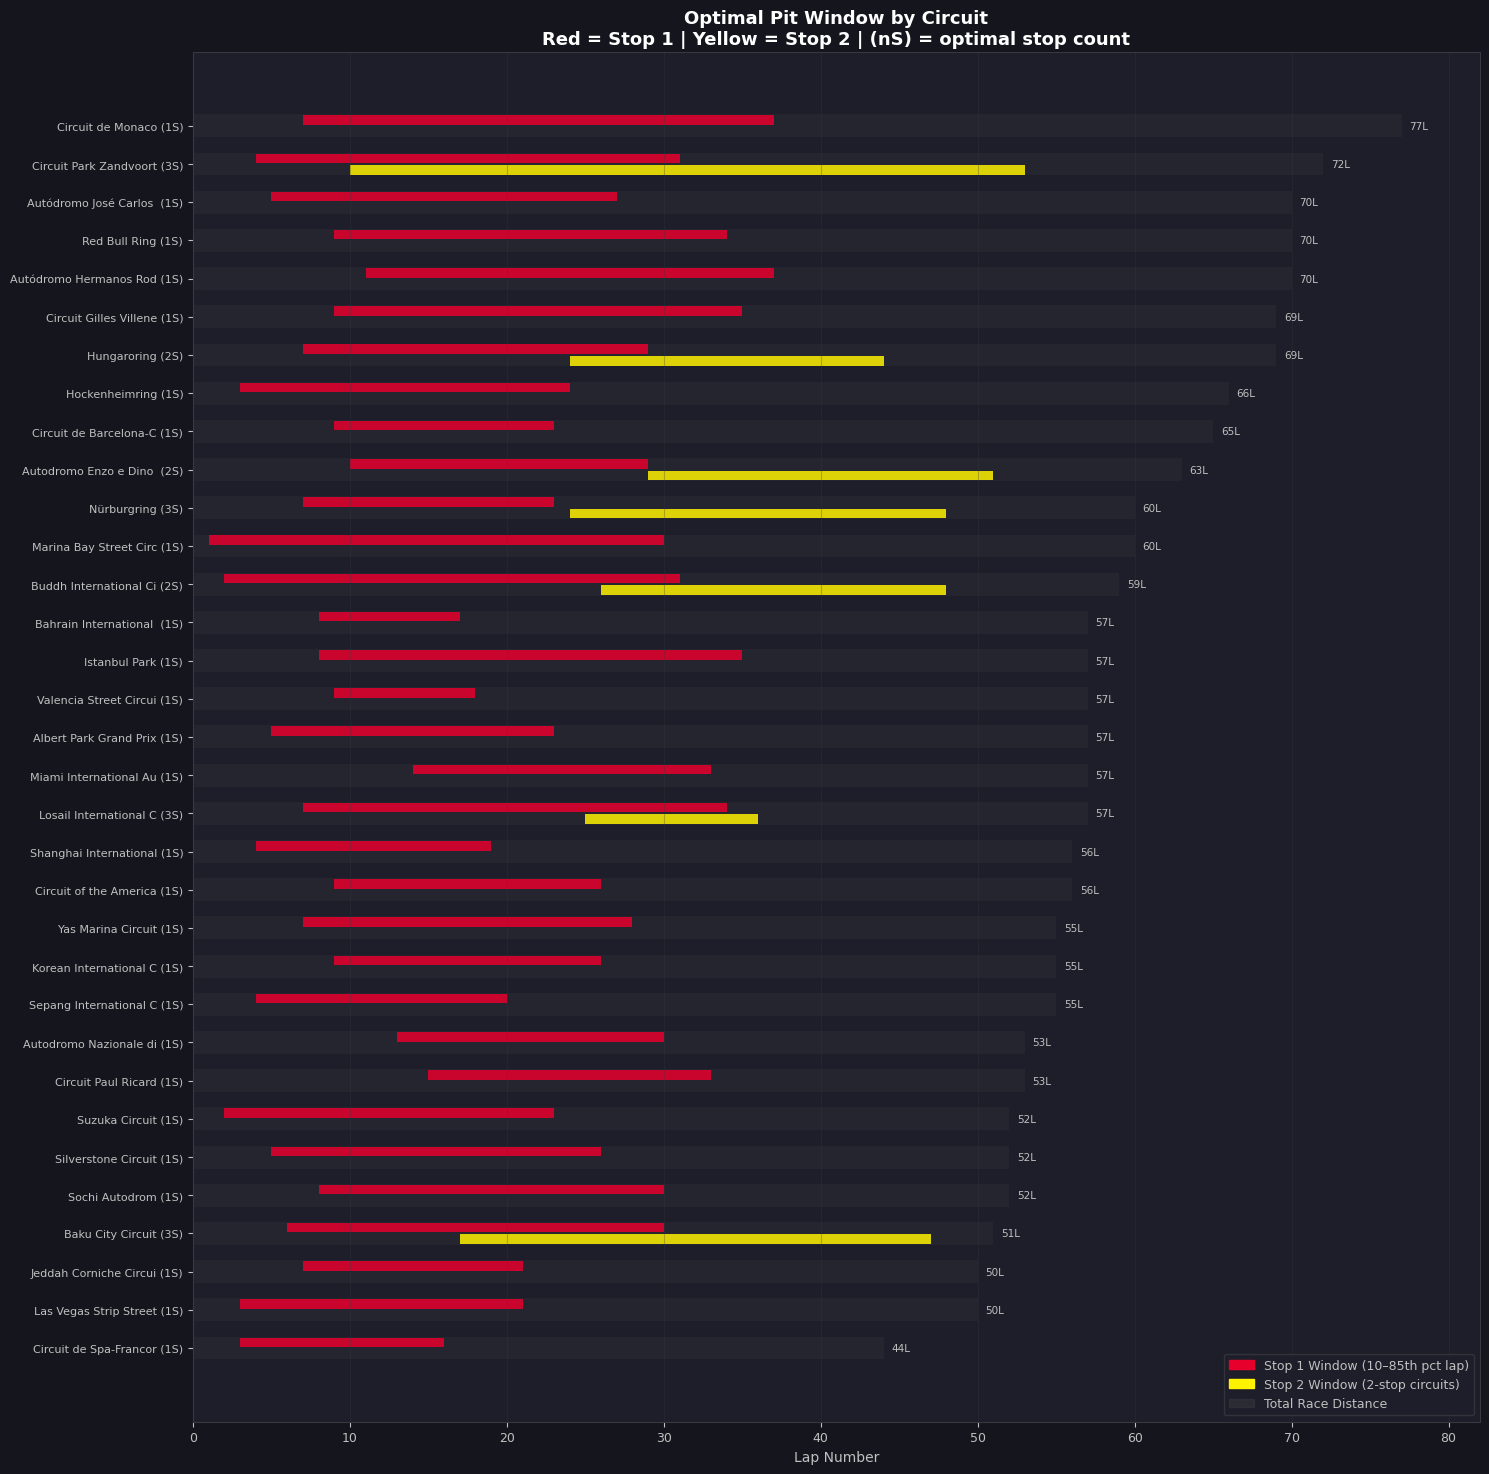

[STEP 4] Chart saved: track_04_pit_windows.png


In [30]:
# ── Chart 4: Pit window timeline per circuit ──────────────────────────────────
pw_plot = pit_window_df.copy()
pw_plot = pw_plot.sort_values('total_laps', ascending=True)

fig, ax = plt.subplots(figsize=(15, max(7, len(pw_plot) * 0.45)))
y_pos = np.arange(len(pw_plot))

# Total race distance bar (background)
ax.barh(y_pos, pw_plot['total_laps'], color=F1_GREY, alpha=0.3,
        height=0.6, label='Race Distance')

# Stop 1 window
s1_width = pw_plot['stop1_window_hi'] - pw_plot['stop1_window_lo']
ax.barh(y_pos + 0.15, s1_width, left=pw_plot['stop1_window_lo'],
        color=F1_RED, height=0.25, alpha=0.85, label='Stop 1 Window')

# Stop 2 window (dashed for 1-stop circuits)
for i, row in pw_plot.reset_index(drop=True).iterrows():
    if row['optimal_stops'] >= 2:
        s2_w = row['stop2_window_hi'] - row['stop2_window_lo']
        ax.barh(i - 0.15, s2_w, left=row['stop2_window_lo'],
                color='#FFF200', height=0.25, alpha=0.85)

# Add lap labels at end of each bar
for i, row in pw_plot.reset_index(drop=True).iterrows():
    ax.text(row['total_laps'] + 0.5, i, f"{int(row['total_laps'])}L",
            va='center', ha='left', fontsize=7.5, color=F1_SILVER)

ax.set_yticks(y_pos)
ax.set_yticklabels(
    [f"{r['circuit_name'][:22]} ({r['optimal_stops']}S)"
     for _, r in pw_plot.iterrows()],
    fontsize=8
)
ax.set_xlabel('Lap Number')
ax.set_title('Optimal Pit Window by Circuit\n'
             'Red = Stop 1 | Yellow = Stop 2 | (nS) = optimal stop count',
             color=F1_WHITE)

# Custom legend
legend_patches = [
    mpatches.Patch(color=F1_RED,    label='Stop 1 Window (10–85th pct lap)'),
    mpatches.Patch(color='#FFF200', label='Stop 2 Window (2-stop circuits)'),
    mpatches.Patch(color=F1_GREY,   label='Total Race Distance', alpha=0.5),
]
ax.legend(handles=legend_patches, loc='lower right')
ax.set_xlim(0, pw_plot['total_laps'].max() + 5)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}track_04_pit_windows.png', dpi=150, bbox_inches='tight',
            facecolor=F1_DARK)
plt.show()
print('[STEP 4] Chart saved: track_04_pit_windows.png')

## Section 5 — Qualifying Lock-In Score per Circuit

**Qualifying Lock-In Score** measures how deterministically the starting grid position sets the finishing position at a circuit. It is derived from:
- **Pearson r(grid, positionOrder):** how correlated starting and finishing position are
- **Positions-gained variance:** low variance = positions locked in
- Combined into a 0–100 score where 100 = completely locked in (Monaco-type)

In [31]:
# ── Pearson r and delta std per circuit ───────────────────────────────────────
lock_results = []

for ckt_id, grp in scope.groupby('circuitId'):
    grp_clean = grp[grp['grid'].notna() & grp['positionOrder'].notna()]
    if len(grp_clean) < 15:   # need enough data for a reliable correlation
        continue
    r, p        = stats.pearsonr(grp_clean['grid'], grp_clean['positionOrder'])
    delta_std   = grp_clean['grid_to_finish_delta'].dropna().std()
    delta_mean  = grp_clean['grid_to_finish_delta'].dropna().mean()
    n_races     = grp_clean['raceId'].nunique()
    ckt_name    = grp_clean['circuit_name'].iloc[0]
    country     = grp_clean['country'].iloc[0]

    lock_results.append({
        'circuitId':   ckt_id,
        'circuit_name': ckt_name,
        'country':     country,
        'corr_r':      r,
        'corr_p':      p,
        'delta_std':   delta_std,
        'delta_mean':  delta_mean,
        'n_races':     n_races,
        'significant': p < ALPHA,
    })

lock_df = pd.DataFrame(lock_results)

# ── Compute qualifying lock-in score (0–100) ──────────────────────────────────
# r → [0,1]: higher r = more locked in
# delta_std → [0,1]: lower std = more locked in → invert and normalize
r_norm       = (lock_df['corr_r'] - lock_df['corr_r'].min()) / \
               (lock_df['corr_r'].max() - lock_df['corr_r'].min() + 1e-9)
std_norm_inv = 1 - ((lock_df['delta_std'] - lock_df['delta_std'].min()) / \
                    (lock_df['delta_std'].max() - lock_df['delta_std'].min() + 1e-9))

lock_df['lock_score'] = ((r_norm * 0.6) + (std_norm_inv * 0.4)) * 100
lock_df['lock_score'] = lock_df['lock_score'].round(1)

# ── Label tier ────────────────────────────────────────────────────────────────
p33 = lock_df['lock_score'].quantile(0.33)
p67 = lock_df['lock_score'].quantile(0.67)
lock_df['qual_dominance'] = pd.cut(
    lock_df['lock_score'],
    bins=[-1, p33, p67, 101],
    labels=['Strategy-Friendly', 'Balanced', 'Qualifying-Critical']
)

# Merge back into ckt_agg
ckt_agg = ckt_agg.merge(
    lock_df[['circuitId','corr_r','corr_p','delta_std','delta_mean',
              'lock_score','qual_dominance']],
    on='circuitId', how='left'
)

print('[STEP 5] Lock-in score stats:')
display(lock_df[['circuit_name','corr_r','delta_std','lock_score','qual_dominance']]
        .sort_values('lock_score', ascending=False).head(15).round(3))

[STEP 5] Lock-in score stats:


,circuit_name,corr_r,delta_std,lock_score,qual_dominance
29,Autódromo Internacional do Algarve,0.852,3.148,97.3,Qualifying-Critical
16,Nürburgring,0.865,3.297,96.6,Qualifying-Critical
24,Buddh International Circuit,0.872,3.368,96.5,Qualifying-Critical
30,Jeddah Corniche Circuit,0.823,3.243,91.9,Qualifying-Critical
5,Circuit de Monaco,0.834,3.394,90.9,Qualifying-Critical
22,Korean International Circuit,0.858,3.632,90.3,Qualifying-Critical
20,Autódromo Hermanos Rodríguez,0.826,3.369,90.3,Qualifying-Critical
3,Circuit de Barcelona-Catalunya,0.820,3.539,86.7,Qualifying-Critical
14,Shanghai International Circuit,0.820,3.701,84.1,Qualifying-Critical
21,Circuit Paul Ricard,0.795,3.512,83.8,Qualifying-Critical


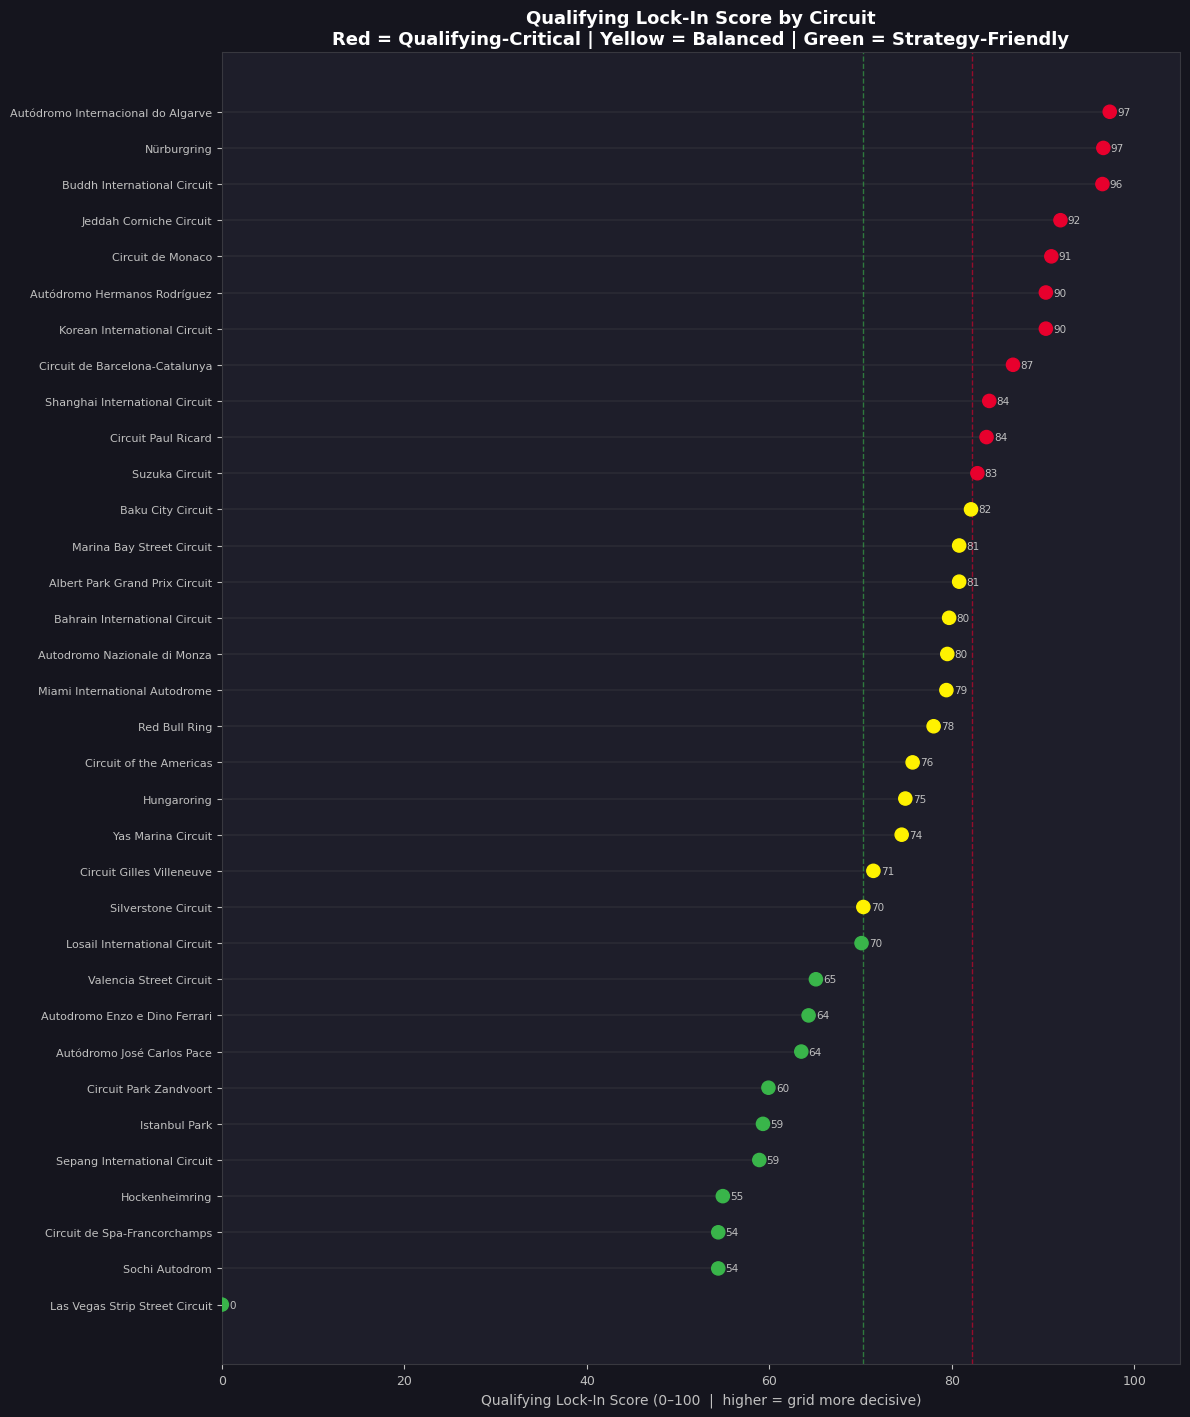

[STEP 5] Chart saved: track_05_lock_in_score.png


In [32]:
# ── Chart 5: Qualifying lock-in score — ranked lollipop ───────────────────────
lock_plot = lock_df.sort_values('lock_score', ascending=True).copy()
lock_plot['color'] = lock_plot['qual_dominance'].map({
    'Qualifying-Critical':  F1_RED,
    'Balanced':             '#FFF200',
    'Strategy-Friendly':    '#39B54A',
}).fillna(F1_GREY)

fig, ax = plt.subplots(figsize=(12, max(7, len(lock_plot) * 0.42)))
y_pos   = np.arange(len(lock_plot))

ax.hlines(y_pos, 0, lock_plot['lock_score'], colors=F1_GREY, linewidth=1.2, alpha=0.5)
ax.scatter(lock_plot['lock_score'], y_pos, color=lock_plot['color'],
           s=90, zorder=5)

for i, (_, row) in enumerate(lock_plot.iterrows()):
    ax.text(row['lock_score'] + 0.8, i, f"{row['lock_score']:.0f}",
            va='center', fontsize=7.5, color=F1_SILVER)

ax.set_yticks(y_pos)
ax.set_yticklabels(lock_plot['circuit_name'], fontsize=8)
ax.set_xlabel('Qualifying Lock-In Score (0–100  |  higher = grid more decisive)')
ax.set_title('Qualifying Lock-In Score by Circuit\n'
             'Red = Qualifying-Critical | Yellow = Balanced | Green = Strategy-Friendly',
             color=F1_WHITE)
ax.axvline(p33, color='#39B54A', linewidth=1, linestyle='--', alpha=0.6)
ax.axvline(p67, color=F1_RED,    linewidth=1, linestyle='--', alpha=0.6)
ax.set_xlim(0, 105)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}track_05_lock_in_score.png', dpi=150, bbox_inches='tight',
            facecolor=F1_DARK)
plt.show()
print('[STEP 5] Chart saved: track_05_lock_in_score.png')

## Section 6 — Grid-to-Finish Delta Distribution per Circuit

For each circuit we show the **distribution of positions gained/lost** for each starting grid band (P1–5, P6–10, P11–15, P16+). This tells a strategist:
- How many positions a mid-field car (P8–12 qualifier) can realistically expect to gain
- Where the highest-variance opportunities lie (upside and downside)

In [33]:
# ── Delta by grid band per circuit ────────────────────────────────────────────
delta_df = scope[
    scope['grid_to_finish_delta'].notna() &
    scope['grid'].notna()
].copy()

delta_df['grid_band'] = pd.cut(
    delta_df['grid'],
    bins=[0, 5, 10, 15, 25],
    labels=['P1–5', 'P6–10', 'P11–15', 'P16+']
)

# Per-circuit × grid-band: mean delta, std, and 10/90 pct
delta_agg = (
    delta_df
    .groupby(['circuitId', 'circuit_name', 'grid_band'], observed=True)
    .agg(
        mean_delta = ('grid_to_finish_delta', 'mean'),
        std_delta  = ('grid_to_finish_delta', 'std'),
        p10_delta  = ('grid_to_finish_delta', lambda x: x.quantile(0.10)),
        p90_delta  = ('grid_to_finish_delta', lambda x: x.quantile(0.90)),
        n          = ('resultId',             'count'),
    )
    .reset_index()
)

# Focus on mid-field starting band (P6–10) — primary use case
midfield_delta = delta_agg[delta_agg['grid_band'] == 'P6–10'].copy()
ckt_agg = ckt_agg.merge(
    midfield_delta[['circuitId','mean_delta','std_delta','p10_delta','p90_delta']]
    .rename(columns={'mean_delta': 'mf_mean_delta', 'std_delta': 'mf_std_delta',
                     'p10_delta': 'mf_p10_delta', 'p90_delta': 'mf_p90_delta'}),
    on='circuitId', how='left'
)

print('[STEP 6] Mid-field (P6–10) expected position change per circuit:')
display(
    ckt_agg[['circuit_name','mf_mean_delta','mf_std_delta','mf_p10_delta','mf_p90_delta']]
    .sort_values('mf_mean_delta', ascending=False)
    .round(2)
    .head(15)
)

[STEP 6] Mid-field (P6–10) expected position change per circuit:


,circuit_name,mf_mean_delta,mf_std_delta,mf_p10_delta,mf_p90_delta
28,Baku City Circuit,1.63,2.63,-2.0,5.0
16,Nürburgring,1.45,3.27,-1.0,5.0
0,Albert Park Grand Prix Circuit,0.72,2.90,-3.0,4.0
30,Losail International Circuit,0.69,3.99,-5.0,4.8
22,Korean International Circuit,0.67,3.12,-3.0,3.6
6,Circuit Gilles Villeneuve,0.42,3.31,-4.0,4.1
1,Sepang International Circuit,0.35,3.66,-5.0,4.0
10,Valencia Street Circuit,0.31,3.64,-3.4,3.8
8,Hockenheimring,0.25,2.85,-3.7,2.7
12,Autodromo Nazionale di Monza,0.24,2.97,-4.0,3.0


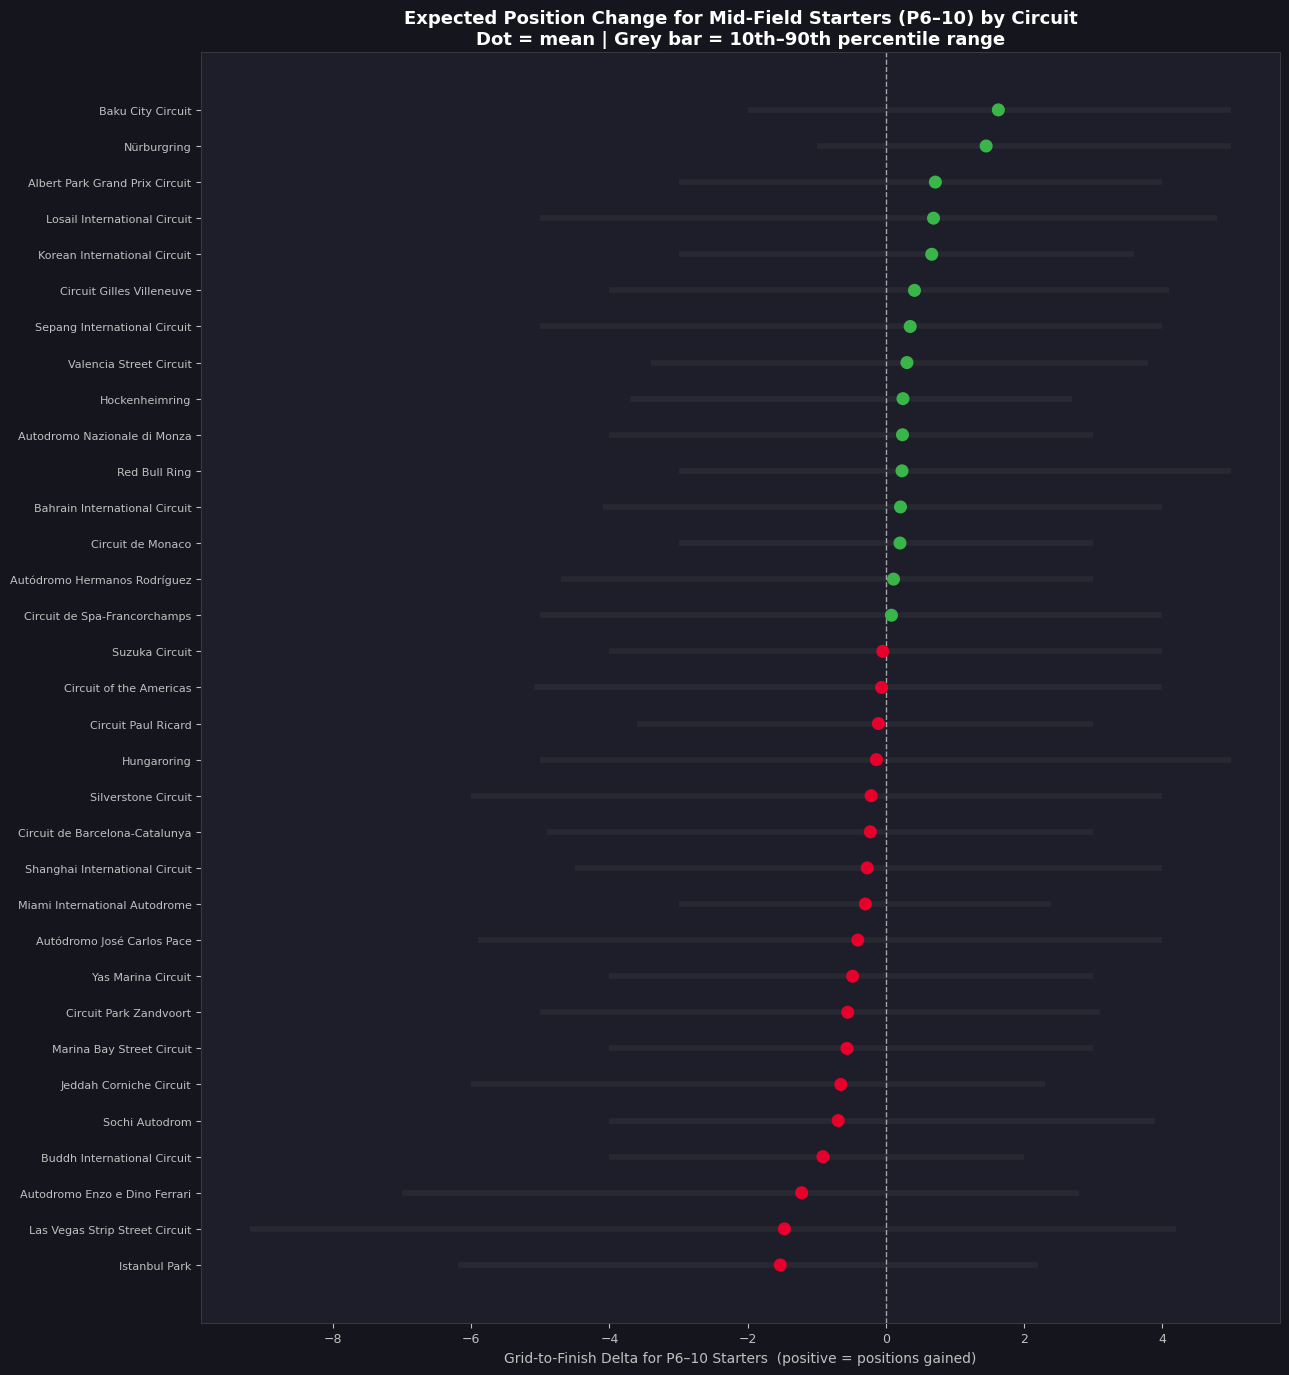

[STEP 6] Chart saved: track_06_midfield_delta.png


In [34]:
# ── Chart 6: Mid-field delta range — error bar chart ──────────────────────────
mf_plot = ckt_agg[
    ckt_agg['mf_mean_delta'].notna()
].sort_values('mf_mean_delta', ascending=True).copy()

fig, ax = plt.subplots(figsize=(13, max(7, len(mf_plot) * 0.42)))
y_pos   = np.arange(len(mf_plot))

# Shaded range: p10–p90
for i, (_, row) in enumerate(mf_plot.iterrows()):
    lo = row['mf_p10_delta'] if pd.notna(row['mf_p10_delta']) else row['mf_mean_delta'] - 3
    hi = row['mf_p90_delta'] if pd.notna(row['mf_p90_delta']) else row['mf_mean_delta'] + 3
    ax.hlines(i, lo, hi, colors=F1_GREY, linewidth=4, alpha=0.4)

# Mean delta dot
colors = [F1_RED if v < 0 else '#39B54A' for v in mf_plot['mf_mean_delta']]
ax.scatter(mf_plot['mf_mean_delta'], y_pos, color=colors, s=70, zorder=5)

ax.axvline(0, color=F1_WHITE, linewidth=1, linestyle='--', alpha=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(mf_plot['circuit_name'], fontsize=8)
ax.set_xlabel('Grid-to-Finish Delta for P6–10 Starters  (positive = positions gained)')
ax.set_title('Expected Position Change for Mid-Field Starters (P6–10) by Circuit\n'
             'Dot = mean | Grey bar = 10th–90th percentile range',
             color=F1_WHITE)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}track_06_midfield_delta.png', dpi=150, bbox_inches='tight',
            facecolor=F1_DARK)
plt.show()
print('[STEP 6] Chart saved: track_06_midfield_delta.png')

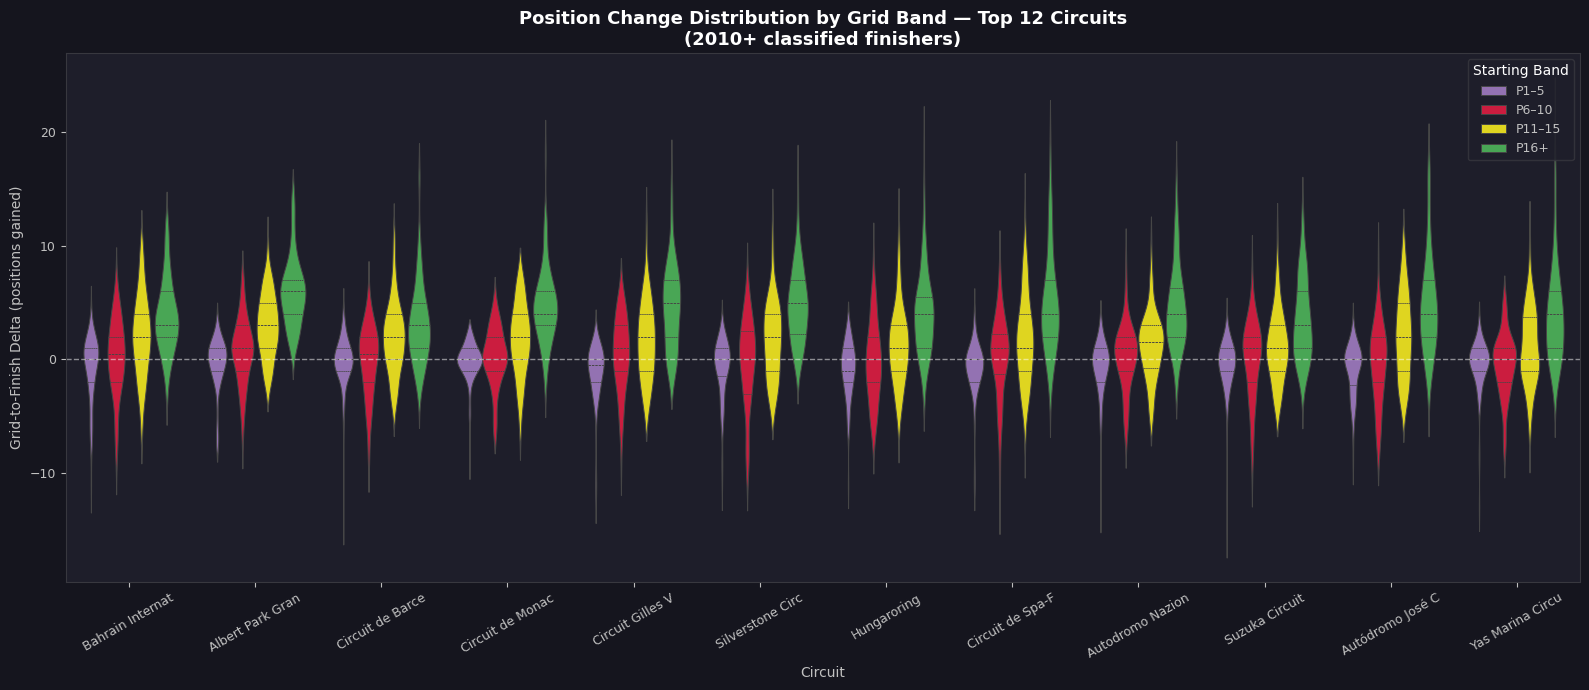

[STEP 6] Chart saved: track_07_delta_violin.png


In [35]:
# ── Chart 7: Multi-circuit violin — grid-to-finish delta by grid band ─────────
# Select top-12 circuits by race count for readability
top_circuits = (
    ckt_agg.nlargest(12, 'n_races')['circuitId'].tolist()
)
violin_df = delta_df[
    delta_df['circuitId'].isin(top_circuits)
][['circuit_name', 'grid_band', 'grid_to_finish_delta']].dropna()

# Shorten long names
violin_df['short_name'] = violin_df['circuit_name'].str[:16]

BAND_PALETTE = {
    'P1–5':   '#9467BD',
    'P6–10':  F1_RED,
    'P11–15': '#FFF200',
    'P16+':   '#39B54A',
}

fig, ax = plt.subplots(figsize=(16, 7))
sns.violinplot(
    data=violin_df,
    x='short_name', y='grid_to_finish_delta',
    hue='grid_band',
    palette=BAND_PALETTE,
    inner='quartile',
    linewidth=0.7,
    ax=ax
)
ax.axhline(0, color=F1_WHITE, linewidth=1, linestyle='--', alpha=0.5)
ax.set_xlabel('Circuit')
ax.set_ylabel('Grid-to-Finish Delta (positions gained)')
ax.set_title('Position Change Distribution by Grid Band — Top 12 Circuits\n'
             '(2010+ classified finishers)',
             color=F1_WHITE)
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Starting Band', loc='upper right')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}track_07_delta_violin.png', dpi=150, bbox_inches='tight',
            facecolor=F1_DARK)
plt.show()
print('[STEP 6] Chart saved: track_07_delta_violin.png')

## Section 7 — Circuit Archetype Benchmarking

Merge all computed metrics with the cluster labels from Notebook 04 and build a **comprehensive strategy benchmark radar** for each archetype, plus a sortable strategy comparison table.

In [36]:
# ── Merge cluster labels from circuit_profile ─────────────────────────────────
cluster_cols = ['circuitId', 'cluster_label', 'overtaking_score',
                'avg_delta', 'avg_qualifying_gap', 'lap_time_variance',
                'avg_1stop_position', 'avg_2stop_position']
cluster_cols = [c for c in cluster_cols if c in ckt_profile.columns]

ckt_profile['circuitId'] = ckt_profile['circuitId'].astype(str)
ckt_agg['circuitId']     = ckt_agg['circuitId'].astype(str)

full_profile = ckt_agg.merge(
    ckt_profile[cluster_cols],
    on='circuitId', how='left'
)

# Also merge pit windows
pit_window_df['circuitId'] = pit_window_df['circuitId'].astype(str)
full_profile = full_profile.merge(
    pit_window_df[['circuitId','total_laps','stop1_window_lo','stop1_window_hi',
                   'stop2_window_lo','stop2_window_hi']],
    on='circuitId', how='left'
)

print(f'[STEP 7] Full strategy profile: {full_profile.shape}')
print(f'[STEP 7] Cluster distribution:')
if 'cluster_label' in full_profile.columns:
    display(full_profile['cluster_label'].value_counts().reset_index())

# ── Print archetype benchmark means ───────────────────────────────────────────
if 'cluster_label' in full_profile.columns:
    benchmark_cols = ['avg_stop_count','pct_1stop','pct_2stop','avg_lap_std',
                      'avg_delta','lock_score','mf_mean_delta']
    benchmark_cols = [c for c in benchmark_cols if c in full_profile.columns]
    bench = full_profile.groupby('cluster_label')[benchmark_cols].mean().round(3)
    print('\n[STEP 7] Archetype benchmark means:')
    display(bench)

[STEP 7] Full strategy profile: (33, 41)
[STEP 7] Cluster distribution:


,cluster_label,count
0,Qualifying-Dominant,21
1,Mixed,12



[STEP 7] Archetype benchmark means:


,avg_stop_count,pct_1stop,pct_2stop,avg_lap_std,lock_score,mf_mean_delta
cluster_label,,,,,,
Mixed,2.060,0.362,0.366,58135.963,75.592,0.077
Qualifying-Dominant,1.926,0.382,0.380,10710.970,72.319,-0.149


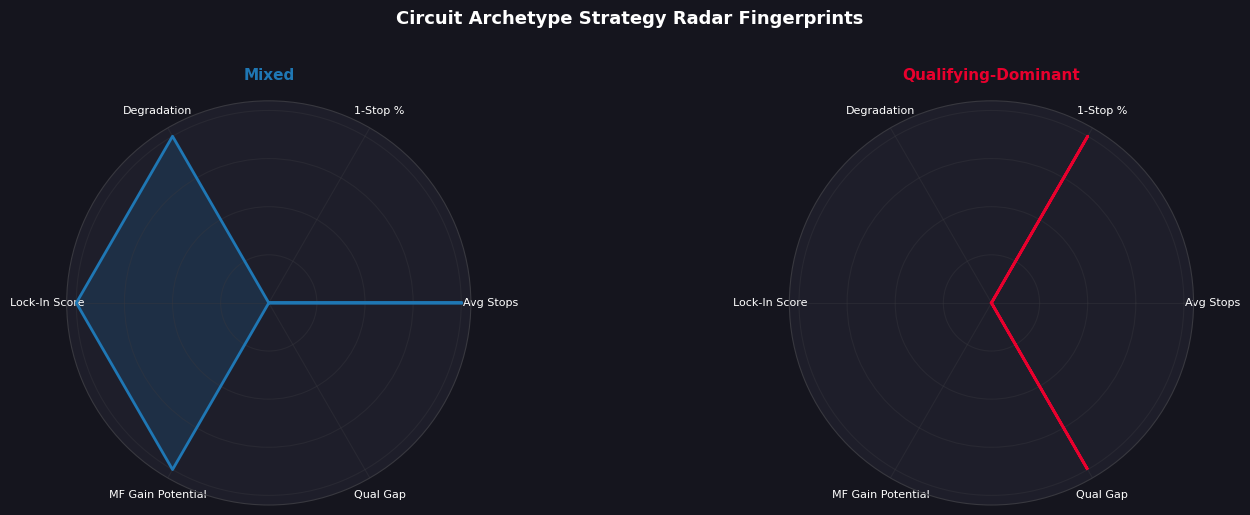

[STEP 7] Chart saved: track_08_archetype_radar.png


In [37]:
# ── Chart 8: Radar chart — archetype strategy fingerprints ────────────────────
# Radar dimensions (normalised 0-1 for each cluster's mean)
RADAR_DIMS = {
    'Avg Stops':          'avg_stop_count',
    '1-Stop %':           'pct_1stop',
    'Degradation':        'avg_lap_std',
    'Position Fluidity':  'avg_delta',       # rescaled: more positive = more fluidity
    'Lock-In Score':      'lock_score',
    'MF Gain Potential':  'mf_mean_delta',
    'Qual Gap':           'avg_qual_gap',
}

# Only use dims that exist
avail_dims = {k: v for k, v in RADAR_DIMS.items() if v in full_profile.columns}

if 'cluster_label' in full_profile.columns and len(avail_dims) >= 4:
    cluster_means = (
        full_profile.groupby('cluster_label')[list(avail_dims.values())]
        .mean()
        .fillna(0)
    )

    # Normalise each dimension to [0, 1]
    for col in cluster_means.columns:
        col_range = cluster_means[col].max() - cluster_means[col].min()
        if col_range > 0:
            cluster_means[col] = (cluster_means[col] - cluster_means[col].min()) / col_range

    labels    = list(avail_dims.keys())
    n_dims    = len(labels)
    angles    = np.linspace(0, 2 * np.pi, n_dims, endpoint=False).tolist()
    angles   += angles[:1]   # close the polygon

    fig, axes = plt.subplots(
        1, len(cluster_means), figsize=(15, 5),
        subplot_kw=dict(polar=True)
    )
    if len(cluster_means) == 1:
        axes = [axes]

    for ax, (cluster_label, row) in zip(axes, cluster_means.iterrows()):
        values = row[list(avail_dims.values())].tolist() + [row[list(avail_dims.values())[0]]]
        color  = CLUSTER_COLORS.get(cluster_label, F1_RED)

        ax.plot(angles, values, color=color, linewidth=2)
        ax.fill(angles, values, color=color, alpha=0.20)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(labels, size=8, color=F1_WHITE)
        ax.set_yticks([0.25, 0.5, 0.75, 1.0])
        ax.set_yticklabels(['', '', '', ''], size=0)
        ax.set_facecolor('#1E1E2A')
        ax.spines['polar'].set_color(F1_GREY)
        ax.grid(color=F1_GREY, alpha=0.4)
        ax.set_title(cluster_label, color=color, fontsize=11, fontweight='bold', pad=15)

    fig.suptitle('Circuit Archetype Strategy Radar Fingerprints',
                 color=F1_WHITE, fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{FIGURES_PATH}track_08_archetype_radar.png', dpi=150, bbox_inches='tight',
                facecolor=F1_DARK)
    plt.show()
    print('[STEP 7] Chart saved: track_08_archetype_radar.png')
else:
    print('[STEP 7] Radar skipped — cluster_label or dimensions not available.')

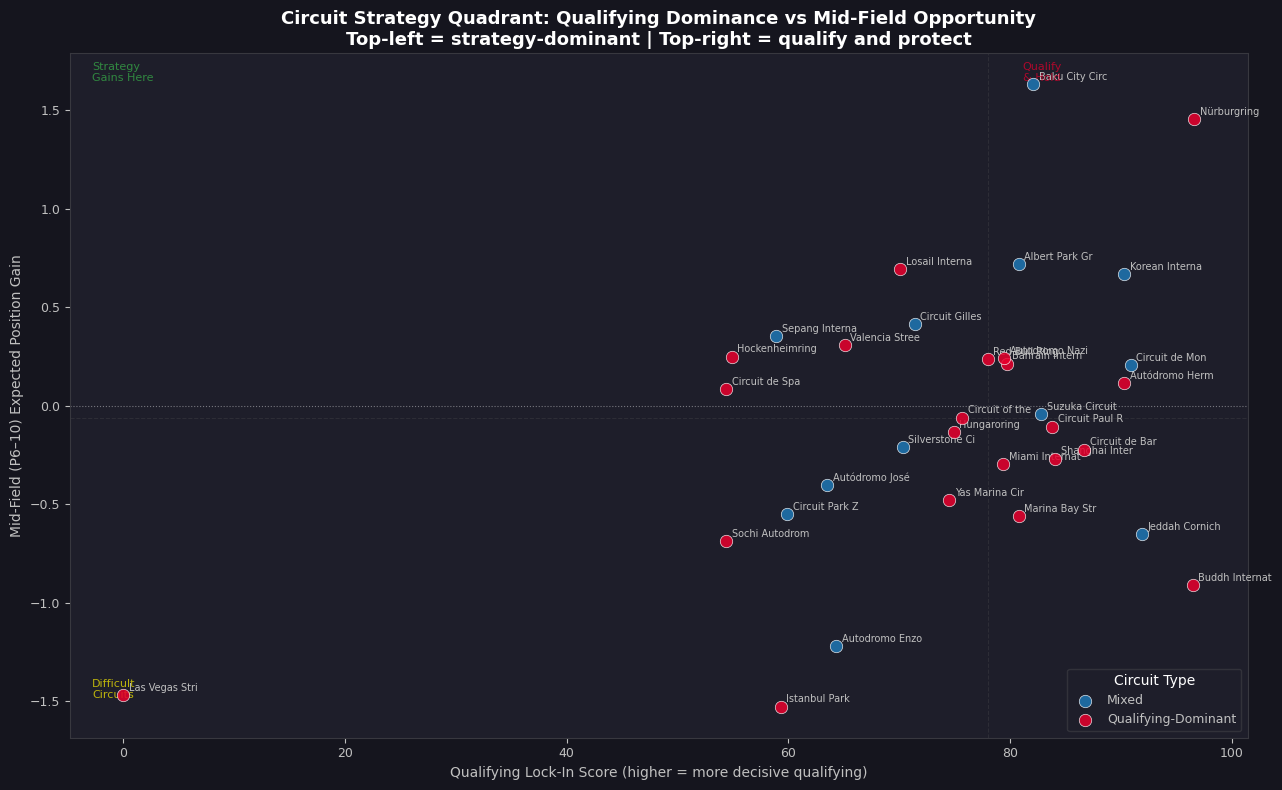

[STEP 7] Chart saved: track_09_strategy_quadrant.png


In [38]:
# ── Chart 9: Strategy quadrant — lock-in score vs avg delta (mid-field) ───────
quad_df = full_profile[
    full_profile['lock_score'].notna() &
    full_profile['mf_mean_delta'].notna()
].copy()

if 'cluster_label' not in quad_df.columns:
    quad_df['cluster_label'] = 'Mixed'

fig, ax = plt.subplots(figsize=(13, 8))

for label, grp in quad_df.groupby('cluster_label'):
    color = CLUSTER_COLORS.get(label, F1_GREY)
    ax.scatter(
        grp['lock_score'], grp['mf_mean_delta'],
        color=color, s=80, alpha=0.85,
        edgecolors='white', linewidths=0.5,
        label=label, zorder=4
    )
    for _, row in grp.iterrows():
        ax.annotate(
            row['circuit_name'][:14],
            (row['lock_score'], row['mf_mean_delta']),
            fontsize=7, color=F1_SILVER,
            xytext=(4, 3), textcoords='offset points'
        )

# Quadrant dividers
mid_lock  = quad_df['lock_score'].median()
mid_delta = quad_df['mf_mean_delta'].median()
ax.axvline(mid_lock,  color=F1_GREY, linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(mid_delta, color=F1_GREY, linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(0, color=F1_WHITE, linewidth=0.8, linestyle=':', alpha=0.4)

# Quadrant labels
x_lo, x_hi = ax.get_xlim()
y_lo, y_hi = ax.get_ylim()
ax.text(x_lo + 2, y_hi * 0.92, 'Strategy\nGains Here', color='#39B54A', fontsize=8, alpha=0.7)
ax.text(x_hi * 0.80, y_hi * 0.92, 'Qualify\n& Hold', color=F1_RED, fontsize=8, alpha=0.7)
ax.text(x_lo + 2, y_lo + 0.2, 'Difficult\nCircuits', color='#FFF200', fontsize=8, alpha=0.7)

ax.set_xlabel('Qualifying Lock-In Score (higher = more decisive qualifying)', fontsize=10)
ax.set_ylabel('Mid-Field (P6–10) Expected Position Gain', fontsize=10)
ax.set_title('Circuit Strategy Quadrant: Qualifying Dominance vs Mid-Field Opportunity\n'
             'Top-left = strategy-dominant | Top-right = qualify and protect',
             color=F1_WHITE)
ax.legend(title='Circuit Type', loc='lower right')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}track_09_strategy_quadrant.png', dpi=150, bbox_inches='tight',
            facecolor=F1_DARK)
plt.show()
print('[STEP 7] Chart saved: track_09_strategy_quadrant.png')

## Section 8 — Master Strategy Profile Table + Export

Assemble all computed metrics into the final `track_strategy_profiles.csv` and generate a plain-text **strategy card** for every circuit.

In [39]:
# ── Assemble final strategy profile table ─────────────────────────────────────
strategy_cols = [
    'circuitId', 'circuit_name', 'country',
    # Cluster / archetype
    'cluster_label', 'overtaking_score',
    # Stop strategy
    'optimal_stops', 'avg_stop_count', 'pct_1stop', 'pct_2stop', 'pct_3stop',
    # Pit windows
    'total_laps', 'stop1_window_lo', 'stop1_window_hi',
    'stop2_window_lo', 'stop2_window_hi',
    # Compound bias
    'compound_bias', 'avg_lap_std', 'deg_rank_pct',
    # Qualifying dominance
    'lock_score', 'qual_dominance', 'corr_r',
    # Delta
    'avg_delta', 'mf_mean_delta', 'mf_std_delta', 'mf_p10_delta', 'mf_p90_delta',
    # Qual gap
    'avg_qual_gap',
    # Pit execution
    'avg_pit_ms', 'fastest_pit_ms',
    # Sample
    'n_races',
]
strategy_cols = [c for c in strategy_cols if c in full_profile.columns]

strategy_table = full_profile[strategy_cols].copy()

# Round floats for readability
float_cols = strategy_table.select_dtypes(include='float').columns
strategy_table[float_cols] = strategy_table[float_cols].round(3)

strategy_table.to_csv(
    os.path.join(PROCESSED_PATH, 'track_strategy_profiles.csv'),
    index=False
)
print(f'[STEP 8] track_strategy_profiles.csv saved: {strategy_table.shape}')
display(strategy_table.head(8))

[STEP 8] track_strategy_profiles.csv saved: (33, 29)


,circuitId,circuit_name,country,cluster_label,overtaking_score,optimal_stops,avg_stop_count,pct_1stop,pct_2stop,pct_3stop,...,qual_dominance,corr_r,mf_mean_delta,mf_std_delta,mf_p10_delta,mf_p90_delta,avg_qual_gap,avg_pit_ms,fastest_pit_ms,n_races
0,1,Albert Park Grand Prix Circuit,Australia,Mixed,Medium,1,2.055,0.364,0.368,0.186,...,Balanced,0.793,0.719,2.902,-3.0,4.0,2329.315,105790.513,49565.105,15
1,2,Sepang International Circuit,Malaysia,Mixed,High,1,2.565,0.229,0.160,0.435,...,Strategy-Friendly,0.737,0.355,3.656,-5.0,4.0,882.062,24957.421,23793.450,8
2,3,Bahrain International Circuit,Bahrain,Qualifying-Dominant,Medium,1,2.440,0.077,0.487,0.370,...,Balanced,0.789,0.214,3.353,-4.1,4.0,1644.681,48504.139,24336.758,16
3,4,Circuit de Barcelona-Catalunya,Spain,Qualifying-Dominant,Low,1,2.397,0.107,0.493,0.307,...,Qualifying-Critical,0.820,-0.222,3.123,-4.9,3.0,1851.965,22512.031,21732.817,16
4,5,Istanbul Park,Turkey,Qualifying-Dominant,Low,1,2.013,0.467,0.227,0.133,...,Strategy-Friendly,0.729,-1.526,3.580,-6.2,2.2,2798.973,23835.400,23053.587,4
5,6,Circuit de Monaco,Monaco,Mixed,High,1,1.638,0.521,0.346,0.112,...,Qualifying-Critical,0.834,0.207,2.546,-3.0,3.0,1641.252,182637.722,122862.804,15
6,7,Circuit Gilles Villeneuve,Canada,Mixed,High,1,2.025,0.356,0.436,0.089,...,Balanced,0.765,0.417,3.310,-4.0,4.1,1696.359,23844.666,22911.754,14
7,9,Silverstone Circuit,UK,Mixed,High,1,1.913,0.285,0.542,0.149,...,Balanced,0.761,-0.211,3.843,-6.0,4.0,2414.770,138042.355,27758.896,17


In [40]:
# ── Generate plain-text strategy cards ────────────────────────────────────────
def build_strategy_card(row: pd.Series) -> str:
    """Return a formatted plain-text strategy card for one circuit."""
    name     = row.get('circuit_name', 'Unknown')[:30]
    country  = row.get('country', '')
    cluster  = row.get('cluster_label', 'Unknown')
    overt    = row.get('overtaking_score', 'N/A')
    bias     = row.get('compound_bias', 'N/A')
    opt_s    = row.get('optimal_stops', 'N/A')
    total_l  = row.get('total_laps', 'N/A')
    s1_lo    = row.get('stop1_window_lo', 'N/A')
    s1_hi    = row.get('stop1_window_hi', 'N/A')
    s2_lo    = row.get('stop2_window_lo', 'N/A')
    s2_hi    = row.get('stop2_window_hi', 'N/A')
    lock_s   = row.get('lock_score', float('nan'))
    qual_dom = row.get('qual_dominance', 'N/A')
    corr_r   = row.get('corr_r', float('nan'))
    mf_mean  = row.get('mf_mean_delta', float('nan'))
    mf_p10   = row.get('mf_p10_delta', float('nan'))
    mf_p90   = row.get('mf_p90_delta', float('nan'))
    avg_pit  = row.get('avg_pit_ms', float('nan'))
    n_races  = row.get('n_races', 'N/A')
    pct_1s   = row.get('pct_1stop', float('nan'))
    pct_2s   = row.get('pct_2stop', float('nan'))

    def fmt_ms(v):
        if pd.isna(v): return 'N/A'
        return f'{v/1000:.2f}s'

    def fmt_f(v, dp=1):
        if pd.isna(v): return 'N/A'
        return f'{v:.{dp}f}'

    def fmt_pct(v):
        if pd.isna(v): return 'N/A'
        return f'{v*100:.0f}%'

    # Build pit window string
    if pd.notna(s1_lo) and pd.notna(s1_hi):
        pit_str = f'Stop 1: Lap {int(s1_lo)}–{int(s1_hi)}'
        if pd.notna(opt_s) and int(opt_s) >= 2 and pd.notna(s2_lo):
            pit_str += f'  |  Stop 2: Lap {int(s2_lo)}–{int(s2_hi)}'
    else:
        pit_str = 'N/A'

    card = (
        f'{'─'*60}\n'
        f'  {name.upper()} — {country}\n'
        f'{'─'*60}\n'
        f'  CIRCUIT TYPE    : {cluster}\n'
        f'  OVERTAKING      : {overt}\n'
  f'  RACE LAPS       : {int(total_l) if pd.notna(total_l) else "N/A"}\n'
        f'  ANALYSIS BASIS  : {n_races} race(s) since {MIN_YEAR}\n'
        f'\n'
        f'  ── TYRE STRATEGY ─────────────────────────────────\n'
        f'  COMPOUND BIAS   : {bias}\n'
        f'  OPTIMAL STOPS   : {int(opt_s) if pd.notna(opt_s) else "N/A"}-stop\n'
        f'  STOP SPLIT      : 1-stop={fmt_pct(pct_1s)} | 2-stop={fmt_pct(pct_2s)}\n'
        f'  PIT WINDOW      : {pit_str}\n'
        f'  AVG PIT TIME    : {fmt_ms(avg_pit)}\n'
        f'\n'
        f'  ── QUALIFYING IMPORTANCE ──────────────────────────\n'
        f'  LOCK-IN SCORE   : {fmt_f(lock_s, 1)} / 100  ({qual_dom})\n'
        f'  GRID CORRELATION: r = {fmt_f(corr_r, 3)}\n'
        f'\n'
        f'  ── MID-FIELD OPPORTUNITY (P6–10 starters) ─────────\n'
        f'  EXPECTED GAIN   : {fmt_f(mf_mean, 2)} positions\n'
        f'  10th pct (floor): {fmt_f(mf_p10, 1)} positions\n'
        f'  90th pct (ceil) : {fmt_f(mf_p90, 1)} positions\n'
        f'\n'
        f'  ── RECOMMENDATION ─────────────────────────────────\n'
    )

    # Context-aware recommendation text
    if cluster == 'Qualifying-Dominant' or (pd.notna(lock_s) and lock_s > 65):
        rec = (f'QUALIFY as high as possible — overtaking is structurally '
               f'limited. Use {opt_s if pd.notna(opt_s) else "1"}-stop with {bias} '
               f'compounds. Pit in Lap {int(s1_lo) if pd.notna(s1_lo) else "30"}–'
               f'{int(s1_hi) if pd.notna(s1_hi) else "45"} to defend track position.')
    elif cluster == 'Strategy-Dominant' or (pd.notna(lock_s) and lock_s < 35):
        rec = (f'RACE strategy matters more than grid here. Target '
               f'{int(opt_s) if pd.notna(opt_s) else 2}-stop with {bias} compounds. '
               f'Undercut window at Lap {int(s1_lo) if pd.notna(s1_lo) else "20"}–'
               f'{int(s1_hi) if pd.notna(s1_hi) else "30"} can gain 2–4 positions.')
    else:
        rec = (f'BALANCED circuit — both qualifying and race strategy matter. '
               f'Use {int(opt_s) if pd.notna(opt_s) else 2}-stop {bias} strategy. '
               f'Expected mid-field gain: {fmt_f(mf_mean, 1)} positions.')

    card += '  ' + '\n  '.join(textwrap.wrap(rec, width=56)) + '\n'
    return card


# Generate and save all cards
report_lines = [
    'F1 RACE STRATEGY INTELLIGENCE — TRACK-WISE STRATEGY CARDS\n',
    'Newton School of Technology | DVA Capstone 2 | Section A Team 4\n',
    f'Analysis scope: {MIN_YEAR}+ | Min races per circuit: {MIN_RACES}\n',
    '=' * 60 + '\n\n',
]

for _, row in strategy_table.sort_values('circuit_name').iterrows():
    card = build_strategy_card(row)
    report_lines.append(card + '\n')

report_path = os.path.join(REPORTS_PATH, 'track_strategy_report.txt')
with open(report_path, 'w', encoding='utf-8') as f:
    f.writelines(report_lines)

print(f'[STEP 8] Strategy cards written: {len(strategy_table)} circuits → {report_path}')

# Preview first 3 cards in notebook
for _, row in strategy_table.sort_values('circuit_name').head(3).iterrows():
    print(build_strategy_card(row))

[STEP 8] Strategy cards written: 33 circuits → ../reports/track_strategy_report.txt
────────────────────────────────────────────────────────────
  ALBERT PARK GRAND PRIX CIRCUIT — Australia
────────────────────────────────────────────────────────────
  CIRCUIT TYPE    : Mixed
  OVERTAKING      : Medium
  RACE LAPS       : 57
  ANALYSIS BASIS  : 15 race(s) since 2010

  ── TYRE STRATEGY ─────────────────────────────────
  COMPOUND BIAS   : MEDIUM-biased
  OPTIMAL STOPS   : 1-stop
  STOP SPLIT      : 1-stop=36% | 2-stop=37%
  PIT WINDOW      : Stop 1: Lap 5–23
  AVG PIT TIME    : 105.79s

  ── QUALIFYING IMPORTANCE ──────────────────────────
  LOCK-IN SCORE   : 80.8 / 100  (Balanced)
  GRID CORRELATION: r = 0.793

  ── MID-FIELD OPPORTUNITY (P6–10 starters) ─────────
  EXPECTED GAIN   : 0.72 positions
  10th pct (floor): -3.0 positions
  90th pct (ceil) : 4.0 positions

  ── RECOMMENDATION ─────────────────────────────────
  QUALIFY as high as possible — overtaking is structurally
  limi

## Section 9 — Summary Dashboard Chart

A single multi-panel figure that a race strategist can pin to their wall: all circuits ranked on every strategic dimension.

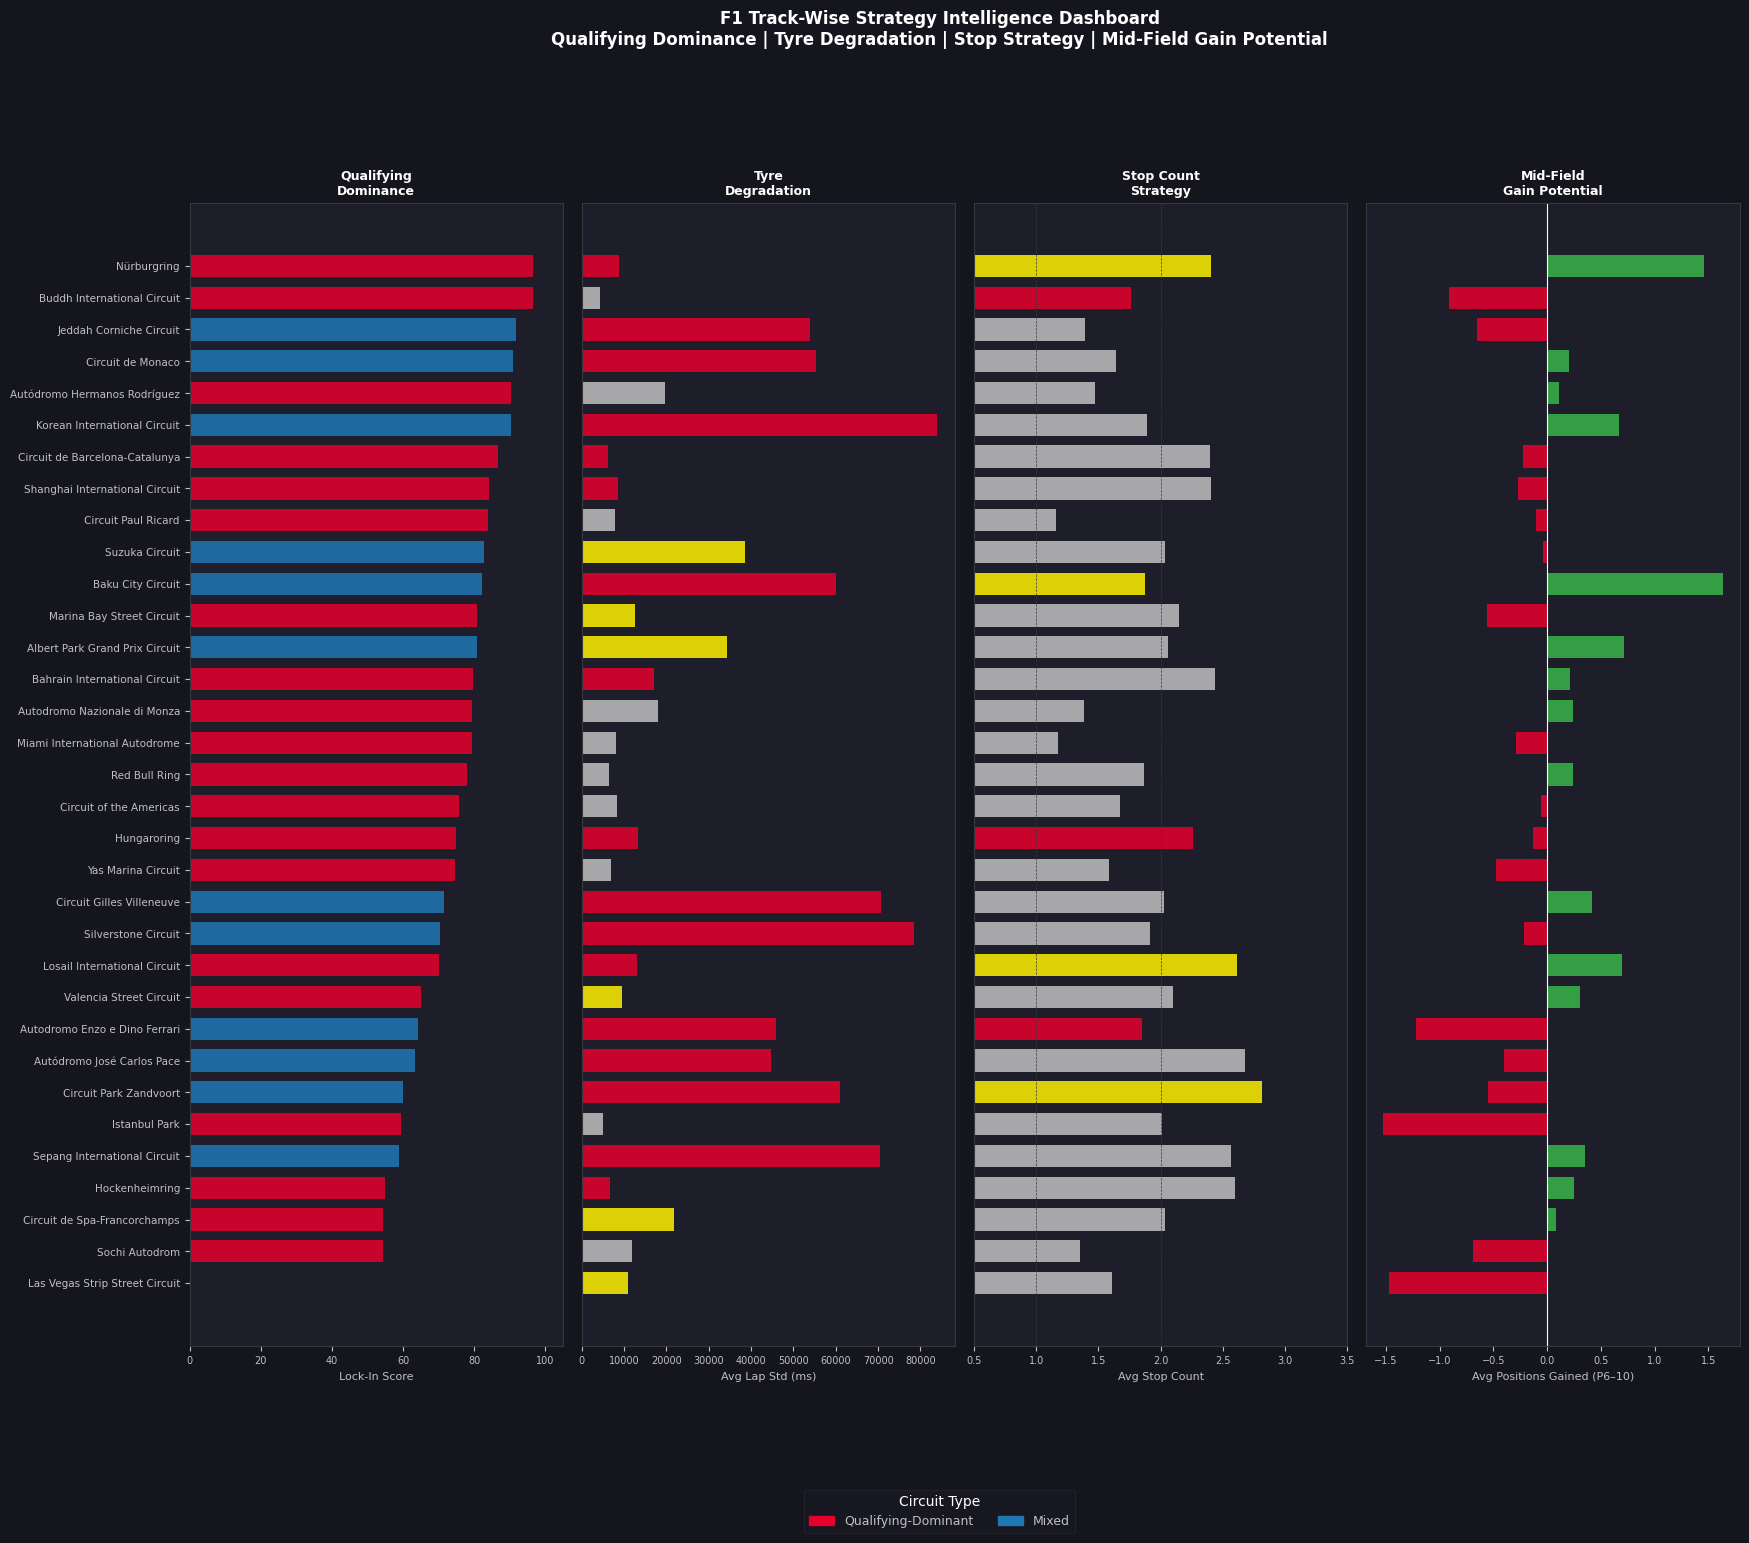

[STEP 9] Chart saved: track_10_master_dashboard.png


In [41]:
# ── Chart 10: Master strategy dashboard (4-panel) ─────────────────────────────
dash_df = strategy_table[
    strategy_table['lock_score'].notna() &
    strategy_table['circuit_name'].notna()
].sort_values('lock_score', ascending=True).copy()

n = len(dash_df)
y = np.arange(n)

if 'cluster_label' not in dash_df.columns:
    dash_df['cluster_label'] = 'Mixed'

cluster_color_vec = dash_df['cluster_label'].map(
    lambda x: CLUSTER_COLORS.get(x, F1_GREY)
)

fig = plt.figure(figsize=(20, max(10, n * 0.45)))
gs  = gridspec.GridSpec(1, 4, wspace=0.05, figure=fig)

# ── Panel 1: Lock-in score ────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.barh(y, dash_df['lock_score'], color=cluster_color_vec, height=0.7, alpha=0.85)
ax1.set_yticks(y)
ax1.set_yticklabels(dash_df['circuit_name'], fontsize=7.5)
ax1.set_xlabel('Lock-In Score', fontsize=8)
ax1.set_title('Qualifying\nDominance', color=F1_WHITE, fontsize=9)
ax1.set_xlim(0, 105)
ax1.tick_params(axis='x', labelsize=7)

# ── Panel 2: Compound bias ────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
bias_map = {'SOFT-biased': F1_RED, 'MEDIUM-biased': '#FFF200', 'HARD-biased': F1_SILVER}
b_colors = dash_df['compound_bias'].map(bias_map).fillna(F1_GREY) if 'compound_bias' in dash_df.columns else [F1_GREY] * n

if 'avg_lap_std' in dash_df.columns:
    # Reorder by lock-in
    ax2.barh(y, dash_df['avg_lap_std'].fillna(0), color=b_colors, height=0.7, alpha=0.85)
    ax2.set_xlabel('Avg Lap Std (ms)', fontsize=8)
else:
    ax2.set_xlabel('N/A', fontsize=8)
ax2.set_yticks([])
ax2.set_title('Tyre\nDegradation', color=F1_WHITE, fontsize=9)
ax2.tick_params(axis='x', labelsize=7)

# ── Panel 3: Optimal stop count ───────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
stop_map  = {1: F1_SILVER, 2: F1_RED, 3: '#FFF200'}
s_colors  = dash_df['optimal_stops'].map(lambda x: stop_map.get(int(x) if pd.notna(x) else 2, F1_GREY))
s_vals    = dash_df['avg_stop_count'].fillna(1.5) if 'avg_stop_count' in dash_df.columns else [2]*n
ax3.barh(y, s_vals, color=s_colors, height=0.7, alpha=0.85)
ax3.set_xlabel('Avg Stop Count', fontsize=8)
ax3.set_yticks([])
ax3.set_title('Stop Count\nStrategy', color=F1_WHITE, fontsize=9)
ax3.set_xlim(0.5, 3.5)
ax3.axvline(1, color=F1_GREY, linewidth=0.5, linestyle='--')
ax3.axvline(2, color=F1_GREY, linewidth=0.5, linestyle='--')
ax3.tick_params(axis='x', labelsize=7)

# ── Panel 4: Mid-field position gain potential ────────────────────────────────
ax4 = fig.add_subplot(gs[3])
if 'mf_mean_delta' in dash_df.columns:
    gain_colors = ['#39B54A' if v > 0 else F1_RED for v in dash_df['mf_mean_delta'].fillna(0)]
    ax4.barh(y, dash_df['mf_mean_delta'].fillna(0), color=gain_colors, height=0.7, alpha=0.85)
    ax4.axvline(0, color=F1_WHITE, linewidth=0.8)
    ax4.set_xlabel('Avg Positions Gained (P6–10)', fontsize=8)
else:
    ax4.set_xlabel('N/A', fontsize=8)
ax4.set_yticks([])
ax4.set_title('Mid-Field\nGain Potential', color=F1_WHITE, fontsize=9)
ax4.tick_params(axis='x', labelsize=7)

# Cluster legend
legend_patches = [
    mpatches.Patch(color=CLUSTER_COLORS[k], label=k)
    for k in CLUSTER_COLORS
    if k in (dash_df['cluster_label'].unique() if 'cluster_label' in dash_df.columns else [])
]
if legend_patches:
    fig.legend(handles=legend_patches, loc='lower center', ncol=3,
               bbox_to_anchor=(0.5, -0.02), fontsize=9, title='Circuit Type',
               framealpha=0.3)

fig.suptitle(
    'F1 Track-Wise Strategy Intelligence Dashboard\n'
    'Qualifying Dominance | Tyre Degradation | Stop Strategy | Mid-Field Gain Potential',
    color=F1_WHITE, fontsize=12, fontweight='bold', y=1.01
)

plt.savefig(f'{FIGURES_PATH}track_10_master_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor=F1_DARK)
plt.show()
print('[STEP 9] Chart saved: track_10_master_dashboard.png')

## Section 10 — Stint-by-Stint Tyre Recommendation

Since the Ergast dataset does **not** contain actual tyre compound labels, we infer the optimal stint-by-stint compound sequence using heuristics derived from our computed **compound bias** (degradation proxy) and **optimal stop count**.

**Logic:**
- **SOFT-biased + 1-stop:** SOFT → MEDIUM (short attack stint, then manage)
- **SOFT-biased + 2-stop:** SOFT → MEDIUM → HARD (step up through compounds)
- **HARD-biased + 1-stop:** MEDIUM → HARD (defend position on durable tyres)
- **HARD-biased + 2-stop:** MEDIUM → HARD → HARD (conservative, low-degradation)
- **MEDIUM-biased + 1-stop:** SOFT → HARD (standard offset strategy)
- **MEDIUM-biased + 2-stop:** SOFT → MEDIUM → HARD (progressive step-up)

The chart below visualises the recommended compound for each stint at every circuit.

[STEP 10] Stint plans generated for 33 circuits


,circuit_name,compound_bias,optimal_stops,stint_plan_str
0,Albert Park Grand Prix Circuit,MEDIUM-biased,1,SOFT → HARD
1,Autodromo Enzo e Dino Ferrari,SOFT-biased,2,SOFT → MEDIUM → HARD
2,Autodromo Nazionale di Monza,HARD-biased,1,MEDIUM → HARD
3,Autódromo Hermanos Rodríguez,HARD-biased,1,MEDIUM → HARD
4,Autódromo José Carlos Pace,SOFT-biased,1,SOFT → MEDIUM
5,Bahrain International Circuit,SOFT-biased,1,SOFT → MEDIUM
6,Baku City Circuit,SOFT-biased,3,SOFT → SOFT → MEDIUM → HARD
7,Buddh International Circuit,HARD-biased,2,MEDIUM → HARD → HARD
8,Circuit Gilles Villeneuve,SOFT-biased,1,SOFT → MEDIUM
9,Circuit Park Zandvoort,SOFT-biased,3,SOFT → SOFT → MEDIUM → HARD


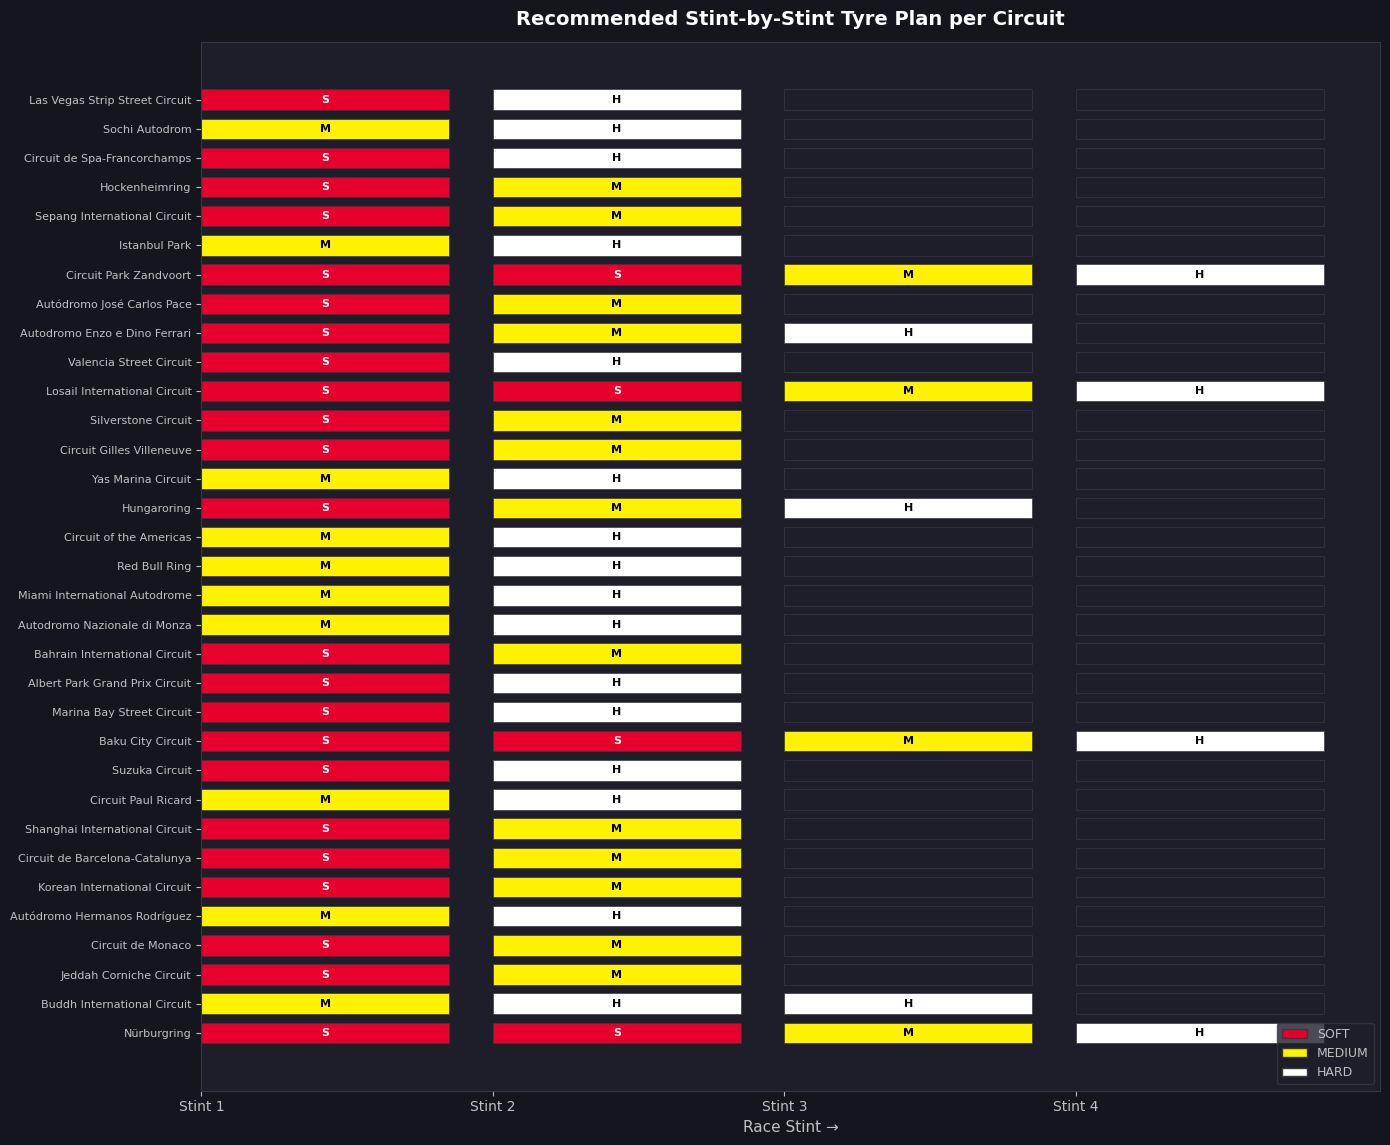

  → Saved: ../reports/figures/track_11_stint_tyre_plan.png


In [42]:
# ── Stint-by-stint tyre recommendation ────────────────────────────────────────

def recommend_stint_tyres(compound_bias, optimal_stops):
    """Infer stint-by-stint compound sequence from bias and stop count."""
    bias = str(compound_bias).upper()
    stops = max(1, int(optimal_stops) if pd.notna(optimal_stops) else 1)
    if stops == 1:
        if "SOFT" in bias:   return ["SOFT", "MEDIUM"]
        elif "HARD" in bias: return ["MEDIUM", "HARD"]
        else:                return ["SOFT", "HARD"]
    elif stops == 2:
        if "SOFT" in bias:   return ["SOFT", "MEDIUM", "HARD"]
        elif "HARD" in bias: return ["MEDIUM", "HARD", "HARD"]
        else:                return ["SOFT", "MEDIUM", "HARD"]
    else:  # 3+
        if "SOFT" in bias:   return ["SOFT", "SOFT", "MEDIUM", "HARD"]
        elif "HARD" in bias: return ["MEDIUM", "HARD", "HARD", "HARD"]
        else:                return ["SOFT", "MEDIUM", "MEDIUM", "HARD"]

# Apply to strategy table
strategy_table["stint_plan"] = strategy_table.apply(
    lambda r: recommend_stint_tyres(r.get("compound_bias", "MEDIUM"), r.get("optimal_stops", 1)),
    axis=1
)
strategy_table["stint_plan_str"] = strategy_table["stint_plan"].apply(lambda x: " → ".join(x))

print(f"[STEP 10] Stint plans generated for {len(strategy_table)} circuits")
display(strategy_table[["circuit_name", "compound_bias", "optimal_stops", "stint_plan_str"]]
        .sort_values("circuit_name").reset_index(drop=True))

# ── Visualisation: Stint Tyre Plan Chart ────────────────────────────────────────
STINT_COLORS = {
    "SOFT":   "#E8002D",   # F1 Red
    "MEDIUM": "#FFF200",   # F1 Yellow
    "HARD":   "#FFFFFF",   # White
}

sorted_table = strategy_table.sort_values("lock_score", ascending=True).reset_index(drop=True)
max_stints = sorted_table["stint_plan"].apply(len).max()

fig, ax = plt.subplots(figsize=(14, max(8, len(sorted_table) * 0.35)))

for stint_idx in range(max_stints):
    lefts = [stint_idx for _ in range(len(sorted_table))]
    widths = [0.85 for _ in range(len(sorted_table))]
    colors = []
    labels_text = []
    for _, row in sorted_table.iterrows():
        plan = row["stint_plan"]
        if stint_idx < len(plan):
            compound = plan[stint_idx]
            colors.append(STINT_COLORS.get(compound, "#888888"))
            labels_text.append(compound[0])  # S, M, H
        else:
            colors.append("none")
            labels_text.append("")

    bars = ax.barh(
        range(len(sorted_table)),
        widths,
        left=lefts,
        color=colors,
        edgecolor=F1_GREY,
        linewidth=0.5,
        height=0.7,
    )
    # Label each bar
    for i, (bar, txt) in enumerate(zip(bars, labels_text)):
        if txt:
            text_color = "#000000" if colors[i] in ["#FFF200", "#FFFFFF"] else "#FFFFFF"
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                txt, ha="center", va="center",
                fontsize=8, fontweight="bold", color=text_color
            )

ax.set_yticks(range(len(sorted_table)))
ax.set_yticklabels(sorted_table["circuit_name"], fontsize=8)
ax.set_xticks(range(max_stints))
ax.set_xticklabels([f"Stint {i+1}" for i in range(max_stints)], fontsize=10)
ax.set_xlabel("Race Stint →", fontsize=11, color=F1_SILVER)
ax.set_title("Recommended Stint-by-Stint Tyre Plan per Circuit", fontsize=14, color=F1_WHITE, pad=12)

# Legend
legend_patches = [
    mpatches.Patch(facecolor="#E8002D", edgecolor=F1_GREY, label="SOFT"),
    mpatches.Patch(facecolor="#FFF200", edgecolor=F1_GREY, label="MEDIUM"),
    mpatches.Patch(facecolor="#FFFFFF", edgecolor=F1_GREY, label="HARD"),
]
ax.legend(handles=legend_patches, loc="lower right", fontsize=9)
ax.invert_yaxis()

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_PATH, "track_11_stint_tyre_plan.png"), dpi=200, bbox_inches="tight")
plt.show()
print(f"  → Saved: {FIGURES_PATH}track_11_stint_tyre_plan.png")

In [43]:
# ── Final summary print ───────────────────────────────────────────────────────
print('=' * 60)
print('NOTEBOOK 05 — TRACK STRATEGY ANALYSIS COMPLETE')
print('=' * 60)
print(f'\nCircuits analysed           : {len(strategy_table)}')
print(f'\nOUTPUT FILES:')
print(f'  data/processed/track_strategy_profiles.csv')
print(f'  reports/track_strategy_report.txt')
print(f'\nCHARTS SAVED (reports/figures/):')
charts = [
    'track_01_compound_bias.png          — Tyre compound classification',
    'track_02_stop_count_heatmap.png     — Mean position by circuit × stops',
    'track_03_stop_distribution.png      — Stop count share per circuit',
    'track_04_pit_windows.png            — Optimal pit window lap ranges',
    'track_05_lock_in_score.png          — Qualifying lock-in ranking',
    'track_06_midfield_delta.png         — Mid-field expected position gain',
    'track_07_delta_violin.png           — Delta distributions by grid band',
    'track_08_archetype_radar.png        — Strategy radar per cluster type',
    'track_09_strategy_quadrant.png      — Qualifying vs strategy quadrant',
    'track_10_master_dashboard.png       — Full strategy intelligence dashboard',
    'track_11_stint_tyre_plan.png        — Stint-by-stint tyre compound plan',
]
for c in charts:
    print(f'  {c}')

print('\nKEY COLUMNS IN track_strategy_profiles.csv:')
for col in strategy_table.columns:
    print(f'  {col}')

NOTEBOOK 05 — TRACK STRATEGY ANALYSIS COMPLETE

Circuits analysed           : 33

OUTPUT FILES:
  data/processed/track_strategy_profiles.csv
  reports/track_strategy_report.txt

CHARTS SAVED (reports/figures/):
  track_01_compound_bias.png          — Tyre compound classification
  track_02_stop_count_heatmap.png     — Mean position by circuit × stops
  track_03_stop_distribution.png      — Stop count share per circuit
  track_04_pit_windows.png            — Optimal pit window lap ranges
  track_05_lock_in_score.png          — Qualifying lock-in ranking
  track_06_midfield_delta.png         — Mid-field expected position gain
  track_07_delta_violin.png           — Delta distributions by grid band
  track_08_archetype_radar.png        — Strategy radar per cluster type
  track_09_strategy_quadrant.png      — Qualifying vs strategy quadrant
  track_10_master_dashboard.png       — Full strategy intelligence dashboard
  track_11_stint_tyre_plan.png        — Stint-by-stint tyre compound plan
